# 📊 SignAlign - Análise de Experimentos (Métricas de TESTE)

Este notebook carrega automaticamente todos os experimentos da pasta `experiments/` e permite:

1. **Comparação de métricas** entre diferentes configurações usando **conjunto de TESTE**
2. **Visualização de curvas** de treinamento
3. **Análise de erros** do conjunto de teste

**IMPORTANTE**: Este notebook usa métricas do conjunto de TESTE (15% do dataset), não validação.


In [1]:
# Imports
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Adicionar path do projeto
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Configurações de plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f"📁 Diretório do projeto: {project_root}")


📁 Diretório do projeto: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit


## 1. 📂 Carregar Experimentos (Métricas de TESTE)


In [2]:
def load_all_experiments(experiments_dir: str = "../experiments"):
    """
    Carrega todos os experimentos de um diretório.
    AGORA USA MÉTRICAS DE TESTE (test_metrics.json) ao invés de validação.
    """
    exp_path = Path(experiments_dir).resolve()
    experiments = []
    
    if not exp_path.exists():
        print(f"⚠️ Diretório {exp_path} não encontrado.")
        return pd.DataFrame()
    
    for exp_dir in exp_path.iterdir():
        if not exp_dir.is_dir():
            continue
        if exp_dir.name == 'internal':
            continue
        
        metadata_path = exp_dir / "metadata.json"
        config_path = exp_dir / "config.json"
        test_metrics_path = exp_dir / "metrics" / "test_metrics.json"
        val_history_path = exp_dir / "metrics" / "val_history.json"
        
        exp_data = {"name": exp_dir.name, "path": str(exp_dir)}
        
        # Metadata
        if metadata_path.exists():
            with open(metadata_path) as f:
                metadata = json.load(f)
                exp_data["best_epoch"] = metadata.get("best_epoch")
                exp_data["best_metric"] = metadata.get("best_metric", {})
        
        # Config
        if config_path.exists():
            with open(config_path) as f:
                config = json.load(f)
                exp_data["model_type"] = config.get("model", {}).get("type")
                exp_data["model_name"] = config.get("model", {}).get("name")
                exp_data["loss_type"] = config.get("loss", {}).get("primary_loss")
                exp_data["use_triplet"] = config.get("loss", {}).get("use_triplet_loss", False)
                exp_data["triplet_weight"] = config.get("loss", {}).get("triplet_weight", 0.0)
                exp_data["freeze_vision"] = config.get("model", {}).get("freeze_vision_encoder", False)
                exp_data["freeze_text"] = config.get("model", {}).get("freeze_text_encoder", False)
                
                # Verificar augmentation
                aug_config = config.get("data", {}).get("augmentation", {})
                if isinstance(aug_config, dict):
                    exp_data["use_augmentation"] = aug_config.get("enabled", True)
                else:
                    exp_data["use_augmentation"] = config.get("data", {}).get("use_augmentation", True)
                
                if "noaug" in exp_dir.name.lower():
                    exp_data["use_augmentation"] = False
                exp_data["epochs"] = config.get("training", {}).get("epochs", 0)
        
        # ===== MÉTRICAS DE TESTE (PRINCIPAL) =====
        if test_metrics_path.exists():
            with open(test_metrics_path) as f:
                test_metrics = json.load(f)
                for key, value in test_metrics.items():
                    exp_data[f"test_{key}"] = value
        else:
            print(f"⚠️ test_metrics.json não encontrado para {exp_dir.name}")
        
        # Carregar val_history para curvas de treinamento (opcional)
        if val_history_path.exists():
            with open(val_history_path) as f:
                val_history = json.load(f)
                exp_data["val_history"] = val_history
                if val_history:
                    last_epoch = val_history[-1]
                    for key, value in last_epoch.items():
                        if key.startswith("val_"):
                            exp_data[key] = value
        
        experiments.append(exp_data)
    
    df = pd.DataFrame(experiments)
    
    # Criar colunas derivadas
    df["finetuned"] = ~(df["freeze_vision"] & df["freeze_text"])
    df["has_augmentation"] = df["use_augmentation"].fillna(True)
    df["has_triplet"] = df["use_triplet"].fillna(False)
    
    # Extrair arquitetura
    def get_architecture(row):
        name = row.get("model_name", "")
        model_type = row.get("model_type", "")
        
        if pd.isna(name):
            name = ""
        name = name.lower()
        
        if "tinyclip" in name:
            return "TinyCLIP"
        elif "siglip" in name:
            return "SigLIP"
        elif "patch16" in name or "vit-b-16" in name or "vit_b_16" in name:
            return "CLIP-B/16"
        elif "patch32" in name or "vit-b-32" in name or "vit_b_32" in name:
            return "CLIP-B/32"
        
        if model_type == "tinyclip":
            return "TinyCLIP"
        elif model_type == "siglip":
            return "SigLIP"
        elif model_type == "clip":
            return "CLIP-B/32"
        
        return "unknown"
    
    df["architecture"] = df.apply(get_architecture, axis=1)
    
    print(f"✅ {len(df)} experimentos carregados com métricas de TESTE.")
    return df

# Carregar experimentos
df_experiments = load_all_experiments()

# Mostrar colunas de teste disponíveis
test_cols = [c for c in df_experiments.columns if c.startswith('test_')]
print(f"\n📊 Métricas de teste disponíveis: {len(test_cols)}")
print(test_cols[:10], "..." if len(test_cols) > 10 else "")


✅ 40 experimentos carregados com métricas de TESTE.

📊 Métricas de teste disponíveis: 33
['test_accuracy_1_neg', 'test_correct_1_neg', 'test_total_1_neg', 'test_num_negative_samples_1_neg', 'test_mean_positive_similarity_1_neg', 'test_std_positive_similarity_1_neg', 'test_mean_negative_similarity_1_neg', 'test_std_negative_similarity_1_neg', 'test_similarity_gap_1_neg', 'test_mrr_1_neg'] ...


In [3]:
# Verificar estrutura dos dados
display_cols = ["name", "architecture", "finetuned", "loss_type", "has_triplet", 
                "triplet_weight", "has_augmentation", 
                "test_accuracy_1_neg", "test_accuracy_2_neg", "test_accuracy_3_neg"]
available_cols = [c for c in display_cols if c in df_experiments.columns]
display(df_experiments[available_cols].head(15))


,name,architecture,finetuned,loss_type,has_triplet,triplet_weight,has_augmentation,test_accuracy_1_neg,test_accuracy_2_neg,test_accuracy_3_neg
0,siglip_sigmoid,SigLIP,True,sigmoid,False,0.2,True,0.895652,0.878261,0.843478
1,tinyclip_combined_tw03_noaug,TinyCLIP,True,infonce,True,0.3,False,0.991304,0.982609,0.913043
2,clip_vit_b32_combined_tw02_noaug,CLIP-B/32,True,infonce,True,0.2,False,0.965217,0.973913,0.930435
3,clip_vit_b32_infonce_noaug,CLIP-B/32,True,infonce,False,0.2,False,0.965217,0.973913,0.939130
4,tinyclip_combined_tw04_noaug,TinyCLIP,True,infonce,True,0.4,False,0.991304,0.991304,0.913043
5,clip_vit_b16_frozen_eval,CLIP-B/16,False,cross_entropy,False,0.2,False,0.973913,0.965217,0.939130
6,clip_vit_b32_combined_tw02,CLIP-B/32,True,infonce,True,0.2,True,0.982609,0.973913,0.973913
7,tinyclip_combined_tw03,TinyCLIP,True,infonce,True,0.3,True,0.991304,0.982609,0.930435
8,tinyclip_combined_tw02,TinyCLIP,True,infonce,True,0.2,True,0.982609,0.982609,0.921739
9,clip_vit_b32_combined_tw05_noaug,CLIP-B/32,True,infonce,True,0.5,False,0.965217,0.956522,0.930435


---
# 📝 Análise para o Artigo (USANDO MÉTRICAS DE TESTE)

## Questões de Pesquisa:

1. **RQ1**: Vale a pena fazer fine-tuning? (Frozen vs Finetuned)
2. **RQ2**: Qual arquitetura é melhor? (TinyCLIP vs CLIP vs SigLIP)
3. **RQ3**: Qual a influência da loss combinada com triplet?
4. **RQ4**: A triplet loss melhora a separação de embeddings?
5. **RQ5**: Qual a influência da augmentação de dados?
6. **RQ6**: Qual o melhor modelo final?


### RQ1: Vale a pena fazer Fine-tuning?
Comparação entre modelos frozen (pré-treinados sem ajuste) vs finetuned (com ajuste fino)


📊 RQ1: IMPACTO DO FINE-TUNING (MÉTRICAS DE TESTE)


,Arquitetura,Acc@1neg (Frozen),Acc@1neg (Finetuned),Δ Acc@1neg,Acc@2neg (Frozen),Acc@2neg (Finetuned),Δ Acc@2neg,Acc@3neg (Frozen),Acc@3neg (Finetuned),Δ Acc@3neg
0,TinyCLIP,0.9130,0.9826,+0.0696,0.9391,0.9913,+0.0522,0.7913,0.9391,+0.1478
1,CLIP-B/32,0.8696,1.0000,+0.1304,0.8261,0.9565,+0.1304,0.7217,0.9565,+0.2348
2,SigLIP,0.6087,0.8957,+0.2870,0.3565,0.8783,+0.5217,0.3304,0.8435,+0.5130


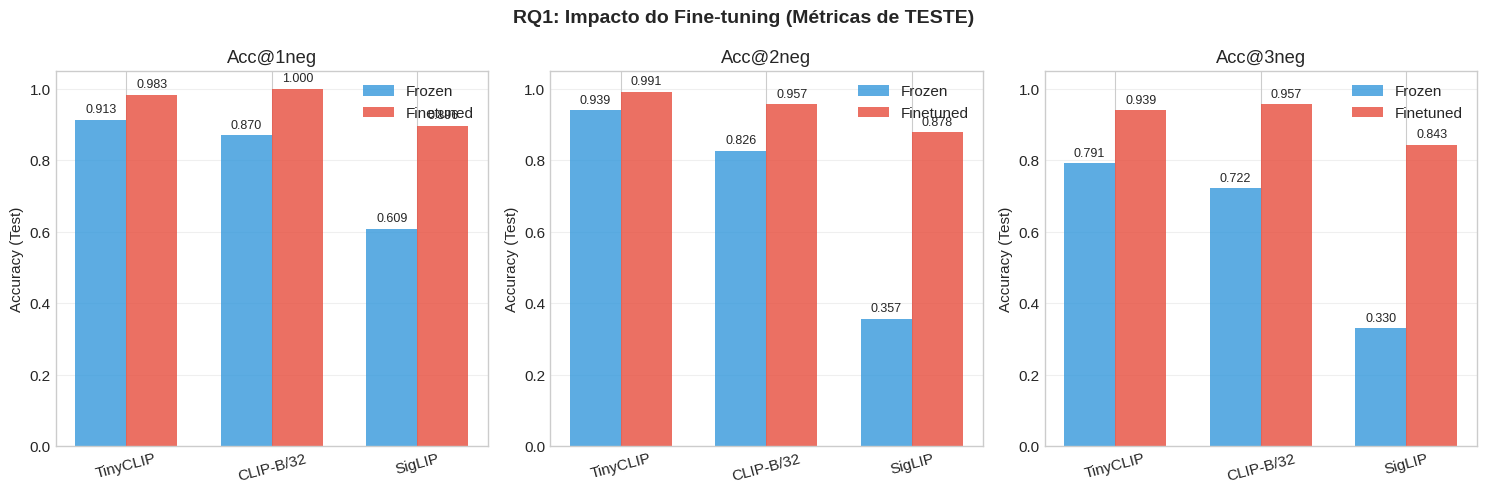

In [4]:
# RQ1: Fine-tuning vs Frozen (MÉTRICAS DE TESTE)
def analyze_finetuning_impact():
    """Analisa o impacto do fine-tuning usando MÉTRICAS DE TESTE."""
    
    frozen = df_experiments[~df_experiments["finetuned"]].copy()
    finetuned = df_experiments[df_experiments["finetuned"]].copy()
    
    baseline_finetuned = finetuned[
        (~finetuned["has_triplet"]) & 
        (finetuned["has_augmentation"])
    ].copy()
    
    print("=" * 80)
    print("📊 RQ1: IMPACTO DO FINE-TUNING (MÉTRICAS DE TESTE)")
    print("=" * 80)
    
    metrics = ["test_accuracy_1_neg", "test_accuracy_2_neg", "test_accuracy_3_neg"]
    metric_labels = ["Acc@1neg", "Acc@2neg", "Acc@3neg"]
    
    results = []
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        frozen_arch = frozen[frozen["architecture"] == arch]
        finetuned_arch = baseline_finetuned[baseline_finetuned["architecture"] == arch]
        
        if len(frozen_arch) > 0 and len(finetuned_arch) > 0:
            row = {"Arquitetura": arch}
            for metric, label in zip(metrics, metric_labels):
                frozen_val = frozen_arch[metric].values[0] if metric in frozen_arch.columns else None
                finetuned_val = finetuned_arch[metric].values[0] if metric in finetuned_arch.columns else None
                
                row[f"{label} (Frozen)"] = f"{frozen_val:.4f}" if frozen_val else "N/A"
                row[f"{label} (Finetuned)"] = f"{finetuned_val:.4f}" if finetuned_val else "N/A"
                
                if frozen_val and finetuned_val:
                    delta = finetuned_val - frozen_val
                    row[f"Δ {label}"] = f"{delta:+.4f}"
            
            results.append(row)
    
    df_results = pd.DataFrame(results)
    display(df_results)
    
    # Visualização
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[idx]
        
        archs = []
        frozen_vals = []
        finetuned_vals = []
        
        for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
            frozen_arch = frozen[frozen["architecture"] == arch]
            finetuned_arch = baseline_finetuned[baseline_finetuned["architecture"] == arch]
            
            if len(frozen_arch) > 0 and len(finetuned_arch) > 0:
                archs.append(arch)
                frozen_vals.append(frozen_arch[metric].values[0] if metric in frozen_arch.columns else 0)
                finetuned_vals.append(finetuned_arch[metric].values[0] if metric in finetuned_arch.columns else 0)
        
        x = np.arange(len(archs))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, frozen_vals, width, label='Frozen', color='#3498db', alpha=0.8)
        bars2 = ax.bar(x + width/2, finetuned_vals, width, label='Finetuned', color='#e74c3c', alpha=0.8)
        
        ax.set_ylabel('Accuracy (Test)')
        ax.set_title(f'{label}')
        ax.set_xticks(x)
        ax.set_xticklabels(archs, rotation=15)
        ax.legend()
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', alpha=0.3)
        
        for bar in bars1 + bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    
    plt.suptitle('RQ1: Impacto do Fine-tuning (Métricas de TESTE)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    Path('article_outputs/img_metrics').mkdir(parents=True, exist_ok=True)
    plt.savefig('article_outputs/img_metrics/rq1_finetuning_impact_test.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return df_results

rq1_results = analyze_finetuning_impact()


### RQ2: Qual arquitetura é a melhor?
Comparação entre TinyCLIP, CLIP-B/32 e SigLIP considerando apenas modelos finetuned baseline


📊 RQ2: COMPARAÇÃO DE ARQUITETURAS (MÉTRICAS DE TESTE)

📈 Resultados Baseline (Finetuned, sem Triplet, com Augmentação) - TESTE:


,Arquitetura,Loss,Acc@1neg,Acc@2neg,Acc@3neg,MRR@1neg,MRR@2neg,MRR@3neg
0,TinyCLIP,infonce,0.982609,0.991304,0.939130,0.991304,0.995652,0.965942
1,CLIP-B/32,infonce,1.000000,0.956522,0.956522,1.000000,0.978261,0.976087
2,SigLIP,sigmoid,0.895652,0.878261,0.843478,0.947826,0.934783,0.911594


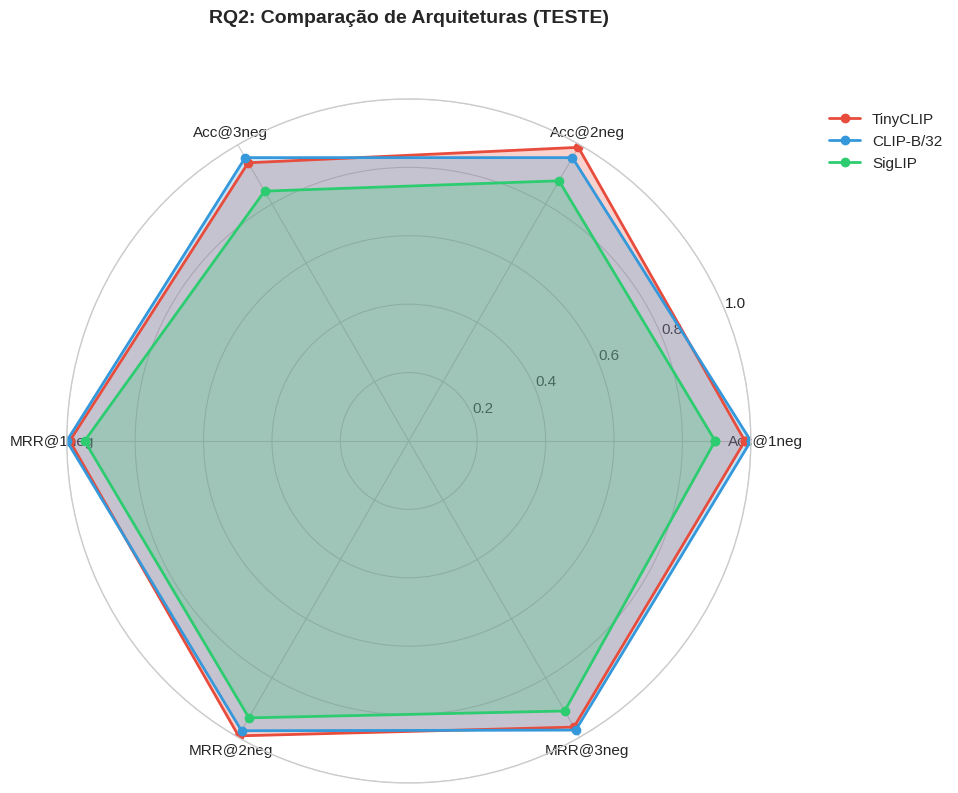


🏆 Melhor arquitetura (Acc@3neg no TESTE): CLIP-B/32


In [5]:
# RQ2: Comparação de Arquiteturas (MÉTRICAS DE TESTE)
def analyze_architectures():
    """Compara as diferentes arquiteturas usando MÉTRICAS DE TESTE."""
    
    baseline = df_experiments[
        (df_experiments["finetuned"]) & 
        (~df_experiments["has_triplet"]) & 
        (df_experiments["has_augmentation"])
    ].copy()
    
    print("=" * 80)
    print("📊 RQ2: COMPARAÇÃO DE ARQUITETURAS (MÉTRICAS DE TESTE)")
    print("=" * 80)
    
    metrics = {
        "test_accuracy_1_neg": "Acc@1neg",
        "test_accuracy_2_neg": "Acc@2neg", 
        "test_accuracy_3_neg": "Acc@3neg",
        "test_mrr_1_neg": "MRR@1neg",
        "test_mrr_2_neg": "MRR@2neg",
        "test_mrr_3_neg": "MRR@3neg"
    }
    
    results = []
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = baseline[baseline["architecture"] == arch]
        if len(arch_data) > 0:
            row = {"Arquitetura": arch, "Loss": arch_data["loss_type"].values[0]}
            for metric, label in metrics.items():
                if metric in arch_data.columns:
                    row[label] = arch_data[metric].values[0]
            results.append(row)
    
    df_results = pd.DataFrame(results)
    
    print("\n📈 Resultados Baseline (Finetuned, sem Triplet, com Augmentação) - TESTE:")
    display(df_results.style.highlight_max(subset=list(metrics.values()), color='lightgreen'))
    
    # Visualização radar chart
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
    
    categories = ["Acc@1neg", "Acc@2neg", "Acc@3neg", "MRR@1neg", "MRR@2neg", "MRR@3neg"]
    num_vars = len(categories)
    angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
    angles += angles[:1]
    
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    
    for idx, row in df_results.iterrows():
        values = [row.get(cat, 0) for cat in categories]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=row["Arquitetura"], color=colors[idx])
        ax.fill(angles, values, alpha=0.25, color=colors[idx])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=11)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.title('RQ2: Comparação de Arquiteturas (TESTE)', size=14, fontweight='bold', y=1.1)
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq2_architecture_comparison_test.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    if "Acc@3neg" in df_results.columns:
        best_arch = df_results.loc[df_results["Acc@3neg"].idxmax(), "Arquitetura"]
        print(f"\n🏆 Melhor arquitetura (Acc@3neg no TESTE): {best_arch}")
    
    return df_results

rq2_results = analyze_architectures()


### RQ3-RQ6: Análises Completas


📊 RQ3: IMPACTO DA TRIPLET LOSS (MÉTRICAS DE TESTE)

📈 Resultados por Peso de Triplet Loss (TESTE):


,Arquitetura,Triplet Weight,Config,Acc@1neg,Acc@2neg,Acc@3neg
6,CLIP-B/32,0.0,Baseline,1.000000,0.956522,0.956522
8,CLIP-B/32,0.1,TW=0.1,0.991304,0.947826,0.965217
7,CLIP-B/32,0.2,TW=0.2,0.982609,0.973913,0.973913
10,CLIP-B/32,0.3,TW=0.3,0.973913,0.956522,0.965217
11,CLIP-B/32,0.4,TW=0.4,0.991304,0.956522,0.973913
9,CLIP-B/32,0.5,TW=0.5,0.991304,0.939130,0.973913
12,SigLIP,0.0,Baseline,0.895652,0.878261,0.843478
15,SigLIP,0.1,TW=0.1,0.913043,0.878261,0.852174
16,SigLIP,0.2,TW=0.2,0.921739,0.886957,0.843478
14,SigLIP,0.3,TW=0.3,0.939130,0.869565,0.852174


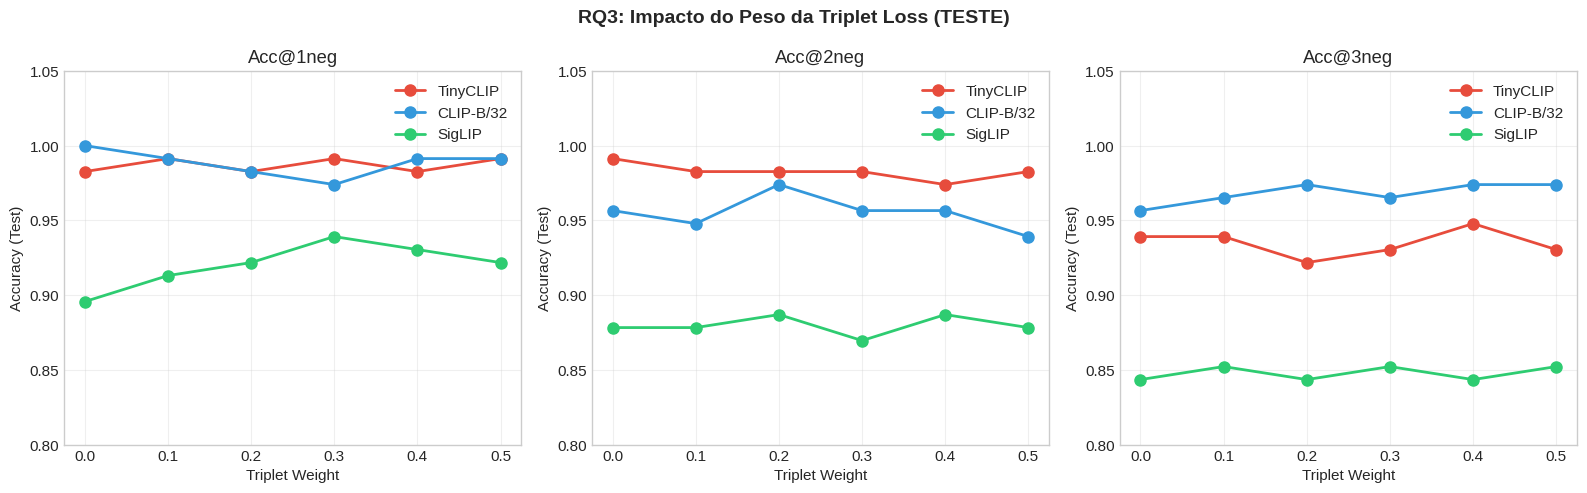


🏆 Melhor configuração por arquitetura (Acc@3neg no TESTE):
   TinyCLIP: TW=0.4 → Acc@3neg=0.9478
   CLIP-B/32: TW=0.2 → Acc@3neg=0.9739
   SigLIP: TW=0.1 → Acc@3neg=0.8522


In [6]:
# RQ3: Influência da Triplet Loss (MÉTRICAS DE TESTE)
def analyze_triplet_loss_impact():
    """Analisa o impacto do peso da triplet loss usando MÉTRICAS DE TESTE."""
    
    finetuned = df_experiments[
        (df_experiments["finetuned"]) & 
        (df_experiments["has_augmentation"])
    ].copy()
    
    print("=" * 80)
    print("📊 RQ3: IMPACTO DA TRIPLET LOSS (MÉTRICAS DE TESTE)")
    print("=" * 80)
    
    results = []
    
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = finetuned[finetuned["architecture"] == arch]
        
        # Baseline (sem triplet)
        baseline = arch_data[~arch_data["has_triplet"]]
        if len(baseline) > 0:
            row = {
                "Arquitetura": arch,
                "Triplet Weight": 0.0,
                "Config": "Baseline",
                "Acc@1neg": baseline["test_accuracy_1_neg"].values[0] if "test_accuracy_1_neg" in baseline.columns else None,
                "Acc@2neg": baseline["test_accuracy_2_neg"].values[0] if "test_accuracy_2_neg" in baseline.columns else None,
                "Acc@3neg": baseline["test_accuracy_3_neg"].values[0] if "test_accuracy_3_neg" in baseline.columns else None,
            }
            results.append(row)
        
        # Com triplet (diferentes pesos)
        triplet_data = arch_data[arch_data["has_triplet"]]
        for _, exp in triplet_data.iterrows():
            tw = exp.get("triplet_weight", 0)
            row = {
                "Arquitetura": arch,
                "Triplet Weight": tw,
                "Config": f"TW={tw}",
                "Acc@1neg": exp.get("test_accuracy_1_neg"),
                "Acc@2neg": exp.get("test_accuracy_2_neg"),
                "Acc@3neg": exp.get("test_accuracy_3_neg"),
            }
            results.append(row)
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(["Arquitetura", "Triplet Weight"])
    
    print("\n📈 Resultados por Peso de Triplet Loss (TESTE):")
    display(df_results)
    
    # Visualização
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    metrics_plot = ["Acc@1neg", "Acc@2neg", "Acc@3neg"]
    colors = {"TinyCLIP": "#e74c3c", "CLIP-B/32": "#3498db", "SigLIP": "#2ecc71"}
    
    for idx, metric in enumerate(metrics_plot):
        ax = axes[idx]
        
        for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
            arch_data = df_results[df_results["Arquitetura"] == arch].sort_values("Triplet Weight")
            if len(arch_data) > 0:
                ax.plot(arch_data["Triplet Weight"], arch_data[metric], 
                       'o-', label=arch, color=colors[arch], linewidth=2, markersize=8)
        
        ax.set_xlabel('Triplet Weight')
        ax.set_ylabel('Accuracy (Test)')
        ax.set_title(f'{metric}')
        ax.legend()
        ax.grid(alpha=0.3)
        ax.set_ylim(0.8, 1.05)
    
    plt.suptitle('RQ3: Impacto do Peso da Triplet Loss (TESTE)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq3_triplet_loss_impact_test.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n🏆 Melhor configuração por arquitetura (Acc@3neg no TESTE):")
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = df_results[df_results["Arquitetura"] == arch]
        if len(arch_data) > 0 and "Acc@3neg" in arch_data.columns:
            arch_data_valid = arch_data.dropna(subset=["Acc@3neg"])
            if len(arch_data_valid) > 0:
                best_idx = arch_data_valid["Acc@3neg"].idxmax()
                best = arch_data_valid.loc[best_idx]
                print(f"   {arch}: TW={best['Triplet Weight']:.1f} → Acc@3neg={best['Acc@3neg']:.4f}")
    
    return df_results

rq3_results = analyze_triplet_loss_impact()


In [ ]:
### RQ4: A Triplet Loss melhora a separação de embeddings?
Análise do gap entre similaridades positivas e negativas para avaliar se a triplet loss ajuda a separar melhor os embeddings no hiperespaço.


In [ ]:
# RQ4: Separação de Embeddings (Análise do Gap)
def analyze_embedding_separation():
    """Analisa se a triplet loss melhora a separação entre embeddings positivos e negativos."""
    
    # Filtrar apenas finetuned com augmentação
    finetuned = df_experiments[
        (df_experiments["finetuned"]) & 
        (df_experiments["has_augmentation"])
    ].copy()
    
    print("=" * 80)
    print("📊 RQ4: SEPARAÇÃO DE EMBEDDINGS (SIMILARITY GAP)")
    print("=" * 80)
    
    # Coletar dados de gap
    results = []
    
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = finetuned[finetuned["architecture"] == arch]
        
        for _, exp in arch_data.iterrows():
            tw = exp.get("triplet_weight", 0) if exp.get("has_triplet", False) else 0
            config = "Baseline" if tw == 0 else f"TW={tw}"
            
            row = {
                "Arquitetura": arch,
                "Triplet Weight": tw,
                "Config": config,
                "Mean Pos Sim": exp.get("mean_pos_sim"),
                "Mean Neg Sim": exp.get("mean_neg_sim"),
                "Gap (Mean)": exp.get("gap_mean"),
                "Median Pos Sim": exp.get("median_pos_sim"),
                "Median Neg Sim": exp.get("median_neg_sim"),
                "Gap (Median)": exp.get("gap_median"),
            }
            results.append(row)
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(["Arquitetura", "Triplet Weight"])
    
    print("\n📈 Estatísticas de Similaridade:")
    display(df_results[["Arquitetura", "Config", "Mean Pos Sim", "Mean Neg Sim", "Gap (Mean)", 
                        "Median Pos Sim", "Median Neg Sim", "Gap (Median)"]].round(4))
    
    # Visualização 1: Gap por triplet weight
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = {"TinyCLIP": "#e74c3c", "CLIP-B/32": "#3498db", "SigLIP": "#2ecc71"}
    
    # Gap médio
    ax = axes[0]
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = df_results[df_results["Arquitetura"] == arch].sort_values("Triplet Weight")
        if len(arch_data) > 0 and "Gap (Mean)" in arch_data.columns:
            ax.plot(arch_data["Triplet Weight"], arch_data["Gap (Mean)"], 
                   'o-', label=arch, color=colors[arch], linewidth=2, markersize=8)
    ax.set_xlabel('Triplet Weight')
    ax.set_ylabel('Similarity Gap')
    ax.set_title('Gap Médio (Pos - Neg)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Gap mediano
    ax = axes[1]
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = df_results[df_results["Arquitetura"] == arch].sort_values("Triplet Weight")
        if len(arch_data) > 0 and "Gap (Median)" in arch_data.columns:
            ax.plot(arch_data["Triplet Weight"], arch_data["Gap (Median)"], 
                   'o-', label=arch, color=colors[arch], linewidth=2, markersize=8)
    ax.set_xlabel('Triplet Weight')
    ax.set_ylabel('Similarity Gap')
    ax.set_title('Gap Mediano (Pos - Neg)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.suptitle('RQ4: Evolução do Gap de Similaridade com Triplet Weight', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq4_similarity_gap.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Visualização 2: Distribuição de similaridades (baseline vs melhor triplet)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, arch in enumerate(["TinyCLIP", "CLIP-B/32", "SigLIP"]):
        ax = axes[idx]
        arch_data = df_results[df_results["Arquitetura"] == arch]
        
        if len(arch_data) > 0:
            # Baseline
            baseline = arch_data[arch_data["Triplet Weight"] == 0]
            if len(baseline) > 0:
                pos_baseline = baseline["Mean Pos Sim"].values[0]
                neg_baseline = baseline["Mean Neg Sim"].values[0]
                ax.barh(["Baseline Neg", "Baseline Pos"], [neg_baseline, pos_baseline], 
                       color=['#ff6b6b', '#4ecdc4'], alpha=0.7, label='Baseline')
            
            # Melhor triplet
            triplet_data = arch_data[arch_data["Triplet Weight"] > 0]
            if len(triplet_data) > 0:
                best_tw = triplet_data.loc[triplet_data["Gap (Mean)"].idxmax()]
                pos_triplet = best_tw["Mean Pos Sim"]
                neg_triplet = best_tw["Mean Neg Sim"]
                ax.barh(["Best TW Neg", "Best TW Pos"], [neg_triplet, pos_triplet],
                       color=['#c44569', '#45b7aa'], alpha=0.7, label=f'TW={best_tw["Triplet Weight"]}')
        
        ax.set_xlabel('Similaridade')
        ax.set_title(arch)
        ax.set_xlim(0, 1)
        ax.legend()
        ax.grid(axis='x', alpha=0.3)
    
    plt.suptitle('RQ4: Comparação Baseline vs Melhor Triplet Weight', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq4_similarity_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Análise estatística: triplet aumentou o gap?
    print("\n📊 Análise: A Triplet Loss aumentou o gap?")
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = df_results[df_results["Arquitetura"] == arch]
        baseline_gap = arch_data[arch_data["Triplet Weight"] == 0]["Gap (Mean)"].values
        triplet_gaps = arch_data[arch_data["Triplet Weight"] > 0]["Gap (Mean)"].values
        
        if len(baseline_gap) > 0 and len(triplet_gaps) > 0:
            baseline_gap = baseline_gap[0]
            best_triplet_gap = max(triplet_gaps)
            delta = best_triplet_gap - baseline_gap
            status = "✅ Melhorou" if delta > 0 else "❌ Não melhorou"
            print(f"   {arch}: Baseline Gap={baseline_gap:.4f}, Best Triplet Gap={best_triplet_gap:.4f}, Δ={delta:+.4f} {status}")
    
    return df_results

rq4_results = analyze_embedding_separation()


📊 RQ5: IMPACTO DA AUGMENTAÇÃO DE DADOS (MÉTRICAS DE TESTE)

📈 Comparação Com/Sem Augmentação (TESTE):


,Arquitetura,Config,Acc@3neg (Aug),Acc@3neg (NoAug),Δ Acc@3neg
0,TinyCLIP,TW=0.1,0.9391,0.9043,0.0348
1,TinyCLIP,TW=0.2,0.9217,0.9217,0.0000
2,TinyCLIP,TW=0.3,0.9304,0.9130,0.0174
3,TinyCLIP,TW=0.4,0.9478,0.9130,0.0348
4,TinyCLIP,TW=0.5,0.9304,0.9217,0.0087
5,CLIP-B/32,TW=0.1,0.9652,0.9478,0.0174
6,CLIP-B/32,TW=0.2,0.9739,0.9304,0.0435
7,CLIP-B/32,TW=0.3,0.9652,0.9304,0.0348
8,CLIP-B/32,TW=0.4,0.9739,0.9478,0.0261
9,CLIP-B/32,TW=0.5,0.9739,0.9304,0.0435


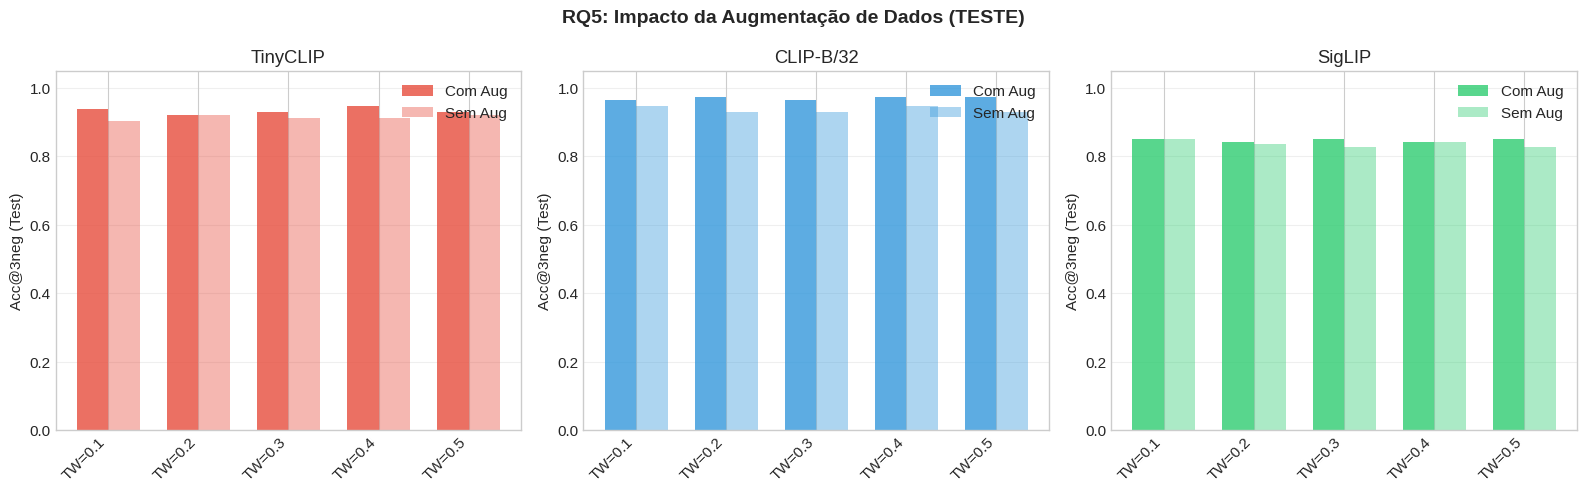


📊 Análise: Augmentação ajudou?
   Δ médio: +0.0214
   Casos onde augmentação ajudou: 12/15 (80.0%)


In [ ]:
# RQ5: Influência da Augmentação de Dados (MÉTRICAS DE TESTE)
def analyze_augmentation_impact():
    """Analisa o impacto da augmentação usando MÉTRICAS DE TESTE."""
    
    finetuned = df_experiments[df_experiments["finetuned"]].copy()
    
    print("=" * 80)
    print("📊 RQ5: IMPACTO DA AUGMENTAÇÃO DE DADOS (MÉTRICAS DE TESTE)")
    print("=" * 80)
    
    results = []
    
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = finetuned[finetuned["architecture"] == arch]
        
        for tw in sorted(arch_data["triplet_weight"].unique()):
            tw_data = arch_data[arch_data["triplet_weight"] == tw]
            
            with_aug = tw_data[tw_data["has_augmentation"]]
            without_aug = tw_data[~tw_data["has_augmentation"]]
            
            if len(with_aug) > 0 and len(without_aug) > 0:
                config = "Baseline" if tw == 0 else f"TW={tw}"
                
                acc3_aug = with_aug["test_accuracy_3_neg"].values[0] if "test_accuracy_3_neg" in with_aug.columns else None
                acc3_noaug = without_aug["test_accuracy_3_neg"].values[0] if "test_accuracy_3_neg" in without_aug.columns else None
                
                row = {
                    "Arquitetura": arch,
                    "Config": config,
                    "Acc@3neg (Aug)": acc3_aug,
                    "Acc@3neg (NoAug)": acc3_noaug,
                    "Δ Acc@3neg": (acc3_aug - acc3_noaug) if acc3_aug and acc3_noaug else None,
                }
                results.append(row)
    
    df_results = pd.DataFrame(results)
    
    print("\n📈 Comparação Com/Sem Augmentação (TESTE):")
    display(df_results[["Arquitetura", "Config", "Acc@3neg (Aug)", "Acc@3neg (NoAug)", "Δ Acc@3neg"]].round(4))
    
    # Visualização
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    colors = {"TinyCLIP": "#e74c3c", "CLIP-B/32": "#3498db", "SigLIP": "#2ecc71"}
    
    for idx, arch in enumerate(["TinyCLIP", "CLIP-B/32", "SigLIP"]):
        ax = axes[idx]
        arch_data = df_results[df_results["Arquitetura"] == arch].reset_index(drop=True)
        
        if len(arch_data) > 0:
            x = np.arange(len(arch_data))
            width = 0.35
            
            aug_vals = arch_data["Acc@3neg (Aug)"].fillna(0)
            noaug_vals = arch_data["Acc@3neg (NoAug)"].fillna(0)
            
            bars1 = ax.bar(x - width/2, aug_vals, width, label='Com Aug', color=colors[arch], alpha=0.8)
            bars2 = ax.bar(x + width/2, noaug_vals, width, label='Sem Aug', color=colors[arch], alpha=0.4)
            
            ax.set_ylabel('Acc@3neg (Test)')
            ax.set_title(arch)
            ax.set_xticks(x)
            ax.set_xticklabels(arch_data["Config"], rotation=45, ha='right')
            ax.legend()
            ax.set_ylim(0, 1.05)
            ax.grid(axis='y', alpha=0.3)
            
            # Valores nas barras
            for bar in bars1:
                height = bar.get_height()
                if height > 0:
                    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                               xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
            for bar in bars2:
                height = bar.get_height()
                if height > 0:
                    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                               xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

    plt.suptitle('RQ5: Impacto da Augmentação de Dados (TESTE)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq5_augmentation_impact_test.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Análise: Augmentação ajudou?")
    deltas = df_results["Δ Acc@3neg"].dropna()
    if len(deltas) > 0:
        mean_delta = deltas.mean()
        positive_count = (deltas > 0).sum()
        total = len(deltas)
        print(f"   Δ médio: {mean_delta:+.4f}")
        print(f"   Casos onde augmentação ajudou: {positive_count}/{total} ({100*positive_count/total:.1f}%)")
    
    return df_results

rq5_results = analyze_augmentation_impact()


📊 RQ6: RANKING FINAL DOS MODELOS (MÉTRICAS DE TESTE)

🏆 TOP 10 Modelos (por Acc@3neg no TESTE):


,Rank,Experimento,Configuração,Acc@1neg,Acc@2neg,Acc@3neg,Similarity Gap
0,1,clip_vit_b32_combined_tw02,CLIP-B/32 | infonce+TW0.2,0.982609,0.973913,0.973913,0.428358
1,2,clip_vit_b32_combined_tw05,CLIP-B/32 | infonce+TW0.5,0.991304,0.939130,0.973913,0.425430
2,3,clip_vit_b32_combined_tw04,CLIP-B/32 | infonce+TW0.4,0.991304,0.956522,0.973913,0.424371
3,4,clip_vit_b32_combined_tw03,CLIP-B/32 | infonce+TW0.3,0.973913,0.956522,0.965217,0.430126
4,5,clip_vit_b32_combined_tw01,CLIP-B/32 | infonce+TW0.1,0.991304,0.947826,0.965217,0.437499
5,6,clip_vit_b32_infonce,CLIP-B/32 | infonce,1.000000,0.956522,0.956522,0.436790
6,7,clip_vit_b32_combined_tw01_noaug,CLIP-B/32 | infonce+TW0.1 | NoAug,0.965217,0.973913,0.947826,0.438195
7,8,clip_vit_b32_combined_tw04_noaug,CLIP-B/32 | infonce+TW0.4 | NoAug,0.973913,0.973913,0.947826,0.433516
8,9,tinyclip_combined_tw04,TinyCLIP | infonce+TW0.4,0.982609,0.973913,0.947826,0.444128
9,10,tinyclip_infonce,TinyCLIP | infonce,0.982609,0.991304,0.939130,0.460787


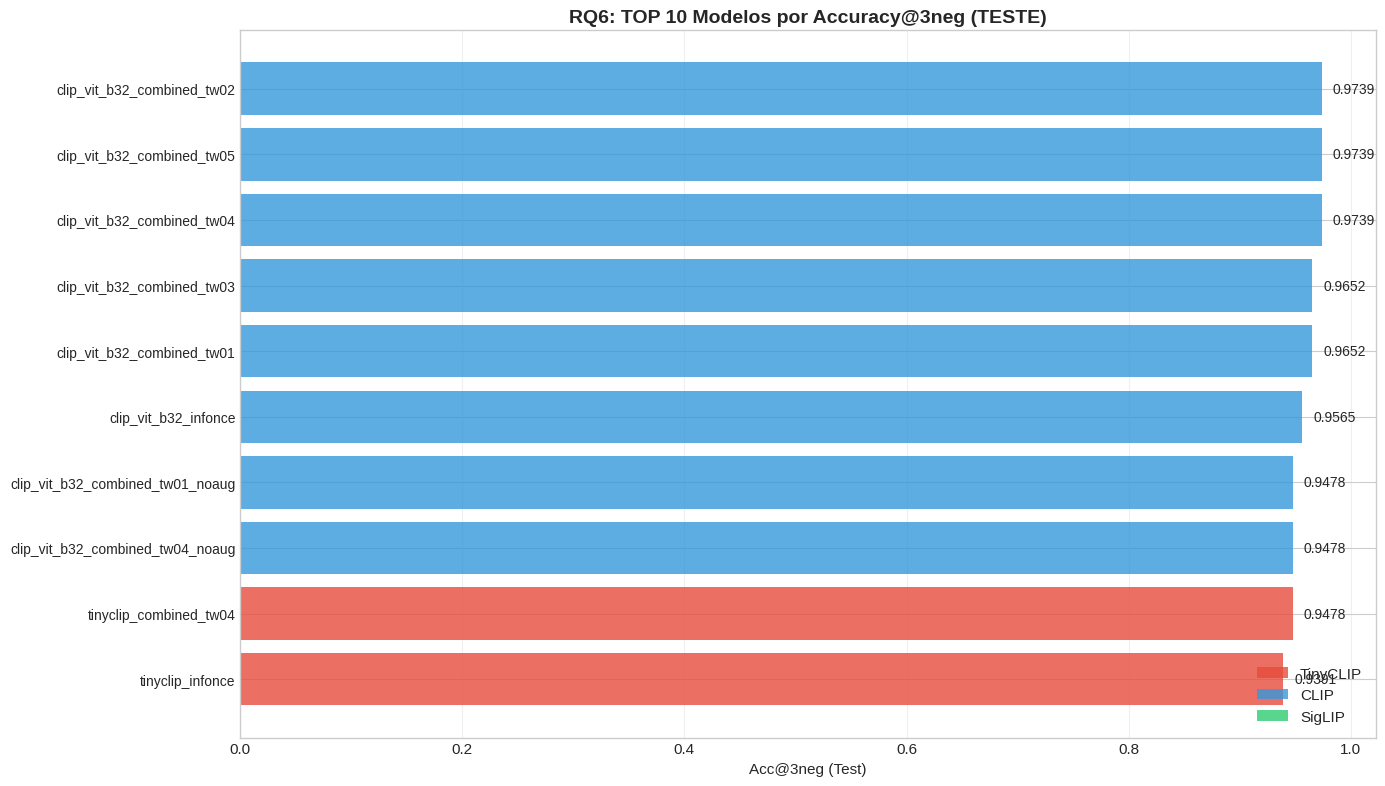


🥇 MELHOR MODELO GERAL (TESTE):
   Experimento: clip_vit_b32_combined_tw02
   Configuração: CLIP-B/32 | infonce+TW0.2
   Acc@1neg: 0.9826
   Acc@2neg: 0.9739
   Acc@3neg: 0.9739

📊 Resumo por Arquitetura (TESTE):
   TinyCLIP: Best Acc@3neg=0.9478, Mean=0.9151, Best Rank=9
   CLIP-B/32: Best Acc@3neg=0.9739, Mean=0.9351, Best Rank=1
   SigLIP: Best Acc@3neg=0.8522, Mean=0.8020, Best Rank=26


In [8]:
# RQ6: Ranking Final (MÉTRICAS DE TESTE)
def create_final_ranking():
    """Cria ranking final usando MÉTRICAS DE TESTE."""
    
    print("=" * 80)
    print("📊 RQ6: RANKING FINAL DOS MODELOS (MÉTRICAS DE TESTE)")
    print("=" * 80)
    
    df_ranking = df_experiments.copy()
    
    def get_config_name(row):
        parts = []
        parts.append(row["architecture"])
        if not row["finetuned"]:
            parts.append("Frozen")
        else:
            loss = row.get("loss_type", "unknown")
            if row.get("has_triplet", False):
                tw = row.get("triplet_weight", 0)
                parts.append(f"{loss}+TW{tw}")
            else:
                parts.append(loss)
            if not row.get("has_augmentation", True):
                parts.append("NoAug")
        return " | ".join(parts)
    
    df_ranking["Config"] = df_ranking.apply(get_config_name, axis=1)
    
    df_ranking = df_ranking.sort_values("test_accuracy_3_neg", ascending=False).reset_index(drop=True)
    df_ranking["Rank"] = df_ranking.index + 1
    
    display_cols = ["Rank", "name", "Config", "test_accuracy_1_neg", "test_accuracy_2_neg", 
                   "test_accuracy_3_neg", "test_similarity_gap_3_neg"]
    available_cols = [c for c in display_cols if c in df_ranking.columns]
    
    df_display = df_ranking[available_cols].copy()
    df_display.columns = ["Rank", "Experimento", "Configuração", "Acc@1neg", "Acc@2neg", 
                         "Acc@3neg", "Similarity Gap"][:len(available_cols)]
    
    print("\n🏆 TOP 10 Modelos (por Acc@3neg no TESTE):")
    display(df_display.head(10).style.background_gradient(subset=["Acc@3neg"], cmap='Greens'))
    
    # Visualização: Top 10
    fig, ax = plt.subplots(figsize=(14, 8))
    
    top10 = df_display.head(10)
    y_pos = np.arange(len(top10))
    
    def get_color(config):
        if "TinyCLIP" in config:
            return "#e74c3c"
        elif "CLIP" in config:
            return "#3498db"
        elif "SigLIP" in config:
            return "#2ecc71"
        return "#95a5a6"
    
    colors = [get_color(c) for c in top10["Configuração"]]
    
    bars = ax.barh(y_pos, top10["Acc@3neg"], color=colors, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top10["Experimento"], fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Acc@3neg (Test)')
    ax.set_title('RQ6: TOP 10 Modelos por Accuracy@3neg (TESTE)', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    for bar, val in zip(bars, top10["Acc@3neg"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
               f'{val:.4f}', va='center', fontsize=10)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', alpha=0.8, label='TinyCLIP'),
        Patch(facecolor='#3498db', alpha=0.8, label='CLIP'),
        Patch(facecolor='#2ecc71', alpha=0.8, label='SigLIP'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig('article_outputs/img_metrics/rq6_final_ranking_test.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    best = df_display.iloc[0]
    print(f"\n🥇 MELHOR MODELO GERAL (TESTE):")
    print(f"   Experimento: {best['Experimento']}")
    print(f"   Configuração: {best['Configuração']}")
    print(f"   Acc@1neg: {best['Acc@1neg']:.4f}")
    print(f"   Acc@2neg: {best['Acc@2neg']:.4f}")
    print(f"   Acc@3neg: {best['Acc@3neg']:.4f}")
    
    print("\n📊 Resumo por Arquitetura (TESTE):")
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        arch_data = df_ranking[df_ranking["architecture"] == arch]
        if len(arch_data) > 0 and "test_accuracy_3_neg" in arch_data.columns:
            best_acc = arch_data["test_accuracy_3_neg"].max()
            mean_acc = arch_data["test_accuracy_3_neg"].mean()
            best_rank = arch_data["Rank"].min()
            print(f"   {arch}: Best Acc@3neg={best_acc:.4f}, Mean={mean_acc:.4f}, Best Rank={best_rank}")
    
    return df_display

rq6_ranking = create_final_ranking()


## 📝 Resumo Final para o Artigo


In [9]:
# Resumo Final para o Artigo (MÉTRICAS DE TESTE)
def generate_article_summary():
    """Gera tabelas e resumos formatados para o artigo usando MÉTRICAS DE TESTE."""
    
    print("=" * 80)
    print("📄 RESUMO PARA O ARTIGO (MÉTRICAS DE TESTE)")
    print("=" * 80)
    
    # 1. Tabela: Dataset Statistics
    print("\n📊 TABELA 1: Estatísticas do Dataset")
    dataset_stats = {
        "Métrica": ["Total de Assinaturas", "Assinaturas Identificadas", "Assinaturas UNKNOWN", 
                    "Signatários Únicos", "Documentos", "Split Treino (%)", "Split Validação (%)", "Split Teste (%)"],
        "Valor": [4542, 3647, 895, 753, 2241, 75, 10, 15]
    }
    df_dataset_stats = pd.DataFrame(dataset_stats)
    display(df_dataset_stats)
    
    # 2. Tabela: Main Results - TESTE
    print("\n📊 TABELA 3: Melhores Resultados por Arquitetura (TESTE)")
    
    main_results = []
    for arch in ["TinyCLIP", "CLIP-B/32", "SigLIP"]:
        # Frozen baseline
        frozen = df_experiments[(~df_experiments["finetuned"]) & (df_experiments["architecture"] == arch)]
        if len(frozen) > 0 and "test_accuracy_1_neg" in frozen.columns:
            main_results.append({
                "Arquitetura": arch,
                "Configuração": "Frozen (Pre-trained)",
                "Acc@1neg": frozen["test_accuracy_1_neg"].values[0],
                "Acc@2neg": frozen["test_accuracy_2_neg"].values[0],
                "Acc@3neg": frozen["test_accuracy_3_neg"].values[0],
            })
        
        # Best finetuned
        finetuned = df_experiments[(df_experiments["finetuned"]) & (df_experiments["architecture"] == arch)]
        if len(finetuned) > 0 and "test_accuracy_3_neg" in finetuned.columns:
            best_idx = finetuned["test_accuracy_3_neg"].idxmax()
            best = finetuned.loc[best_idx]
            config = f"Finetuned"
            if best.get("has_triplet", False):
                config += f" + Triplet (w={best['triplet_weight']})"
            if not best.get("has_augmentation", True):
                config += " [NoAug]"
            
            main_results.append({
                "Arquitetura": arch,
                "Configuração": config,
                "Acc@1neg": best["test_accuracy_1_neg"],
                "Acc@2neg": best["test_accuracy_2_neg"],
                "Acc@3neg": best["test_accuracy_3_neg"],
            })
    
    df_main = pd.DataFrame(main_results)
    display(df_main.round(4).style.highlight_max(subset=["Acc@3neg"], color='lightgreen'))
    
    # 3. Conclusões automáticas
    print("\n" + "=" * 80)
    print("📌 CONCLUSÕES PRINCIPAIS (MÉTRICAS DE TESTE)")
    print("=" * 80)
    
    if "test_accuracy_3_neg" in df_experiments.columns:
        frozen_data = df_experiments[~df_experiments["finetuned"]]["test_accuracy_3_neg"].dropna()
        finetuned_data = df_experiments[df_experiments["finetuned"]]["test_accuracy_3_neg"].dropna()
        
        if len(frozen_data) > 0 and len(finetuned_data) > 0:
            frozen_avg = frozen_data.mean()
            finetuned_avg = finetuned_data.mean()
            print(f"\n1. Fine-tuning:")
            print(f"   - Média Acc@3neg Frozen: {frozen_avg:.4f}")
            print(f"   - Média Acc@3neg Finetuned: {finetuned_avg:.4f}")
            print(f"   - Melhoria: {((finetuned_avg - frozen_avg) / frozen_avg * 100):+.1f}%")
    
        best_overall = df_experiments.loc[df_experiments["test_accuracy_3_neg"].idxmax()]
        print(f"\n2. Melhor Arquitetura: {best_overall['architecture']}")
        print(f"   - Experimento: {best_overall['name']}")
        print(f"   - Acc@3neg: {best_overall['test_accuracy_3_neg']:.4f}")
    
    # LaTeX export
    print("\n" + "=" * 80)
    print("📄 EXPORTAÇÃO LATEX")
    print("=" * 80)
    print("\n% Tabela - Main Results (LaTeX)")
    print(df_main.round(4).to_latex(index=False, caption="Melhores resultados por arquitetura (Teste)", label="tab:results_test"))
    
    return df_main

article_summary = generate_article_summary()


📄 RESUMO PARA O ARTIGO (MÉTRICAS DE TESTE)

📊 TABELA 1: Estatísticas do Dataset


,Métrica,Valor
0,Total de Assinaturas,4542
1,Assinaturas Identificadas,3647
2,Assinaturas UNKNOWN,895
3,Signatários Únicos,753
4,Documentos,2241
5,Split Treino (%),75
6,Split Validação (%),10
7,Split Teste (%),15



📊 TABELA 3: Melhores Resultados por Arquitetura (TESTE)


,Arquitetura,Configuração,Acc@1neg,Acc@2neg,Acc@3neg
0,TinyCLIP,Frozen (Pre-trained),0.913000,0.939100,0.791300
1,TinyCLIP,Finetuned + Triplet (w=0.4),0.982600,0.973900,0.947800
2,CLIP-B/32,Frozen (Pre-trained),0.869600,0.826100,0.721700
3,CLIP-B/32,Finetuned + Triplet (w=0.2),0.982600,0.973900,0.973900
4,SigLIP,Frozen (Pre-trained),0.608700,0.356500,0.330400
5,SigLIP,Finetuned + Triplet (w=0.1) [NoAug],0.904300,0.869600,0.852200



📌 CONCLUSÕES PRINCIPAIS (MÉTRICAS DE TESTE)

1. Fine-tuning:
   - Média Acc@3neg Frozen: 0.6957
   - Média Acc@3neg Finetuned: 0.9065
   - Melhoria: +30.3%

2. Melhor Arquitetura: CLIP-B/32
   - Experimento: clip_vit_b32_combined_tw02
   - Acc@3neg: 0.9739

📄 EXPORTAÇÃO LATEX

% Tabela - Main Results (LaTeX)
\begin{table}
\caption{Melhores resultados por arquitetura (Teste)}
\label{tab:results_test}
\begin{tabular}{llrrr}
\toprule
Arquitetura & Configuração & Acc@1neg & Acc@2neg & Acc@3neg \\
\midrule
TinyCLIP & Frozen (Pre-trained) & 0.913000 & 0.939100 & 0.791300 \\
TinyCLIP & Finetuned + Triplet (w=0.4) & 0.982600 & 0.973900 & 0.947800 \\
CLIP-B/32 & Frozen (Pre-trained) & 0.869600 & 0.826100 & 0.721700 \\
CLIP-B/32 & Finetuned + Triplet (w=0.2) & 0.982600 & 0.973900 & 0.973900 \\
SigLIP & Frozen (Pre-trained) & 0.608700 & 0.356500 & 0.330400 \\
SigLIP & Finetuned + Triplet (w=0.1) [NoAug] & 0.904300 & 0.869600 & 0.852200 \\
\bottomrule
\end{tabular}
\end{table}



In [10]:
# Exportar todos os resultados
def export_all_results():
    """Exporta resultados em diferentes formatos."""
    output_dir = Path("article_outputs")
    output_dir.mkdir(exist_ok=True)
    
    print("📁 Exportando resultados para:", output_dir.absolute())
    
    df_experiments.to_csv(output_dir / "all_experiments_test.csv", index=False)
    print("   ✅ all_experiments_test.csv")
    
    rq6_ranking.to_csv(output_dir / "ranking_test.csv", index=False)
    print("   ✅ ranking_test.csv")
    
    print(f"\n✅ Todos os resultados de TESTE exportados para {output_dir.absolute()}")

export_all_results()


📁 Exportando resultados para: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/notebooks/article_outputs
   ✅ all_experiments_test.csv
   ✅ ranking_test.csv

✅ Todos os resultados de TESTE exportados para /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/notebooks/article_outputs


## 📊 Análise de Erros do Teste

Carrega os CSVs de erros para análise detalhada.


In [11]:
def load_test_errors(experiment_name: str, num_neg: int = 3):
    """Carrega erros do teste para um experimento específico."""
    
    exp_path = Path(f"../experiments/{experiment_name}/metrics")
    errors_path = exp_path / f"test_errors_{num_neg}neg.csv"
    results_path = exp_path / f"test_results_{num_neg}neg.csv"
    
    if errors_path.exists():
        df_errors = pd.read_csv(errors_path)
        print(f"❌ {len(df_errors)} erros carregados para {experiment_name} ({num_neg} negativos)")
        return df_errors
    else:
        print(f"⚠️ Arquivo de erros não encontrado: {errors_path}")
        return None

# Carregar erros do melhor modelo
best_model = "clip_vit_b32_combined_tw02"
df_errors = load_test_errors(best_model, num_neg=3)

if df_errors is not None and len(df_errors) > 0:
    display(df_errors.head(10))


❌ 3 erros carregados para clip_vit_b32_combined_tw02 (3 negativos)


,expected_name,image_path,positive_similarity,max_negative_similarity,predicted_rank,is_correct,all_similarities,negative_image_paths
0,J B BODER,datasets/dataset-sign-align/signatures/zlw44e0...,0.293507,0.321898,2,False,"[""0.293507"", ""0.123375"", ""-0.005759"", ""0.321898""]","[""datasets/dataset-sign-align/signatures/kex05..."
1,R DERAMUS,datasets/dataset-sign-align/signatures/gsa_LAR...,-0.075428,0.114472,4,False,"[""-0.075428"", ""-0.037323"", ""0.114472"", ""0.0190...","[""datasets/dataset-sign-align/signatures/nist_..."
2,ROB INGOLD,datasets/dataset-sign-align/signatures/gsa_LAZ...,0.216918,0.219026,2,False,"[""0.216918"", ""0.072956"", ""0.219026"", ""0.092502""]","[""datasets/dataset-sign-align/signatures/nist_..."


In [12]:
# Análise de padrões nos erros
if df_errors is not None and len(df_errors) > 0:
    print("\n📊 Análise de Erros:")
    print(f"   Total de erros: {len(df_errors)}")
    
    if 'positive_similarity' in df_errors.columns:
        print(f"   Similaridade positiva média nos erros: {df_errors['positive_similarity'].mean():.4f}")
    
    if 'predicted_rank' in df_errors.columns:
        print(f"   Rank predito médio: {df_errors['predicted_rank'].mean():.2f}")
        
        print("\n   Distribuição de ranks nos erros:")
        print(df_errors['predicted_rank'].value_counts().sort_index())



📊 Análise de Erros:
   Total de erros: 3
   Similaridade positiva média nos erros: 0.1450
   Rank predito médio: 2.67

   Distribuição de ranks nos erros:
predicted_rank
2    2
4    1
Name: count, dtype: int64


## 3. 🔍 Carregar Modelo para Inferência


In [13]:
from src.inference import SignaturePredictor, SimilarityMatrixVisualizer

# Selecionar o melhor experimento baseado nos resultados de TESTE
SELECTED_EXPERIMENT = "clip_vit_b32_combined_tw02"

predictor = None
if not df_experiments.empty:
    if SELECTED_EXPERIMENT:
        exp_row = df_experiments[df_experiments['name'] == SELECTED_EXPERIMENT].iloc[0]
    else:
        # Usar o melhor experimento de teste
        best_col = [c for c in df_experiments.columns if 'test_accuracy_3' in str(c)]
        if best_col:
            exp_row = df_experiments.loc[df_experiments[best_col[0]].idxmax()]
        else:
            exp_row = df_experiments.iloc[0]
    
    print(f"📌 Experimento selecionado: {exp_row['name']}")
    print(f"   Tipo: {exp_row.get('model_type', 'unknown')}")
    print(f"   Test Acc@3neg: {exp_row.get('test_accuracy_3_neg', 'N/A'):.4f}")
    print(f"   Path: {exp_row['path']}")
    
    try:
        predictor = SignaturePredictor.from_experiment(
            exp_row['path'],
            checkpoint="best",
            model_type=exp_row.get('model_type', 'clip')
        )
        print("✅ Modelo carregado com sucesso!")
    except Exception as e:
        print(f"⚠️ Erro ao carregar modelo: {e}")
        import traceback
        traceback.print_exc()
else:
    print("⚠️ Nenhum experimento encontrado.")


📌 Experimento selecionado: clip_vit_b32_combined_tw02
   Tipo: clip
   Test Acc@3neg: 0.9739
   Path: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/experiments/clip_vit_b32_combined_tw02
📦 Carregando modelo de: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/experiments/clip_vit_b32_combined_tw02/checkpoints/best


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

📂 Modelo carregado de: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/experiments/clip_vit_b32_combined_tw02/checkpoints/best
✅ Modelo carregado em cpu
✅ Modelo carregado com sucesso!


## 4. 📊 Matriz de Similaridade


In [14]:
# Carregar dataset
dataset_path = project_root / "datasets" / "dataset-sign-align" / "dataset.csv"
df_dataset = None

if dataset_path.exists():
    df_dataset = pd.read_csv(dataset_path)
    df_dataset = df_dataset[df_dataset['human_name'] != 'UNKNOWN'].reset_index(drop=True)
    print(f"📊 Dataset carregado: {len(df_dataset)} amostras")
    display(df_dataset.head())
else:
    print(f"⚠️ Dataset não encontrado em: {dataset_path}")


📊 Dataset carregado: 3647 amostras


,document,human_name,llm_name,image_path,source
0,efm53d00,A A MACKINNON,A MACKINNON,signatures/efm53d00_sign3.png,outros
1,cxk72e00-page03_3,ADOLFO KUENNEN,ADOLFO KUENNEN,signatures/cxk72e00-page03_3_sign1.png,outros
2,gsa_LAL50124-SLA-1-_Z-01,ADRIANA SANCHEZ,CHAD SANDS,signatures/gsa_LAL50124-SLA-1-_Z-01_sign3.png,gsa
3,X_031,ALAN X HUM,ALAN L HUM,signatures/X_031_sign1.png,x_dataset
4,nist_r0025_01,ALBUR R BELL,ARTHUR T BELL,signatures/nist_r0025_01_sign2.png,nist



📊 Matriz de Similaridade (5x5)


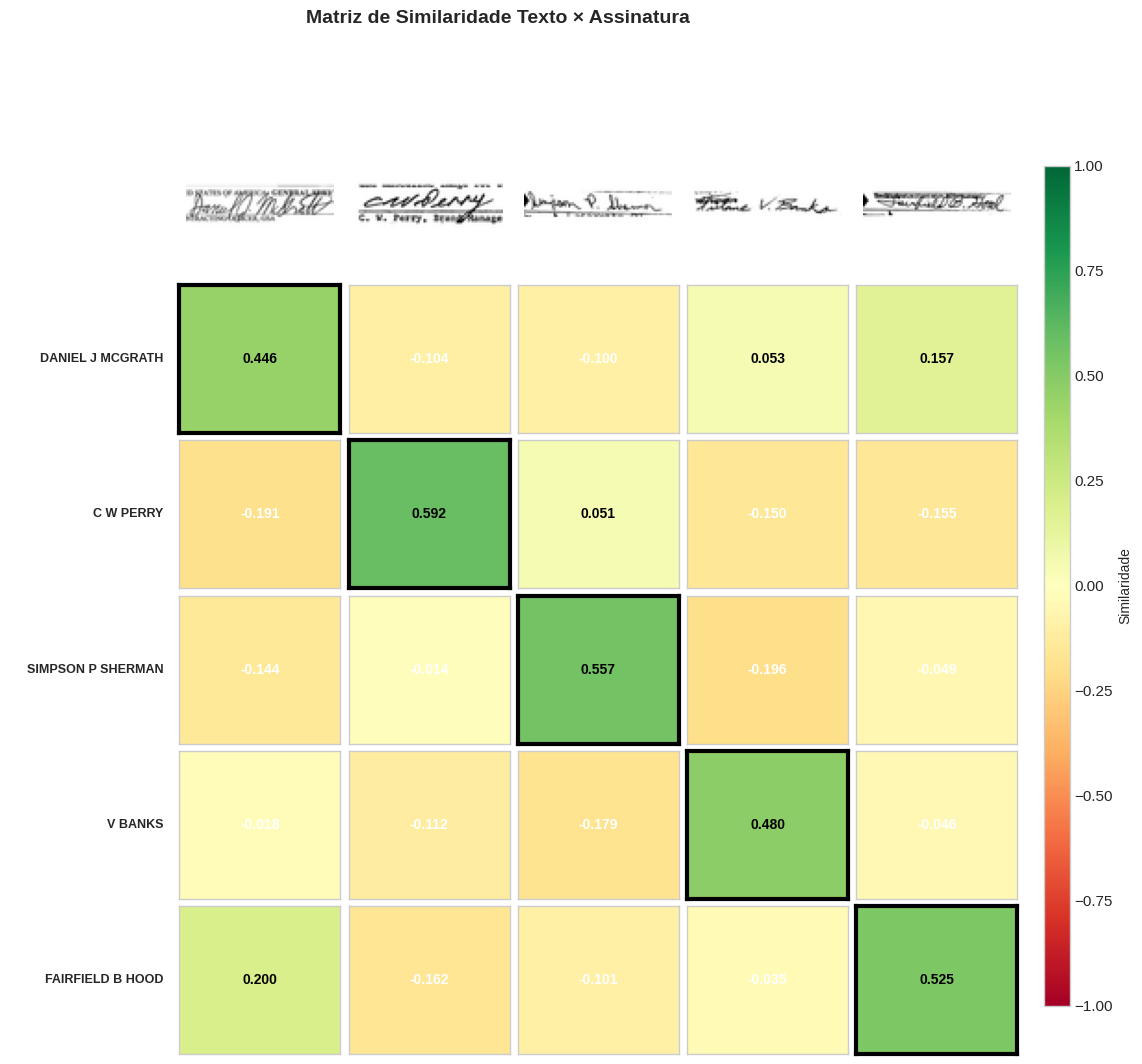

In [15]:
# Criar matriz de similaridade para N textos e N imagens
if predictor is not None and df_dataset is not None:
    N = 5  # Número de amostras
    unique_names = df_dataset['human_name'].unique()
    selected_names = np.random.choice(unique_names, min(N, len(unique_names)), replace=False)
    
    images_base_path = project_root / "datasets" / "dataset-sign-align"
    
    texts = []
    images = []
    for name in selected_names:
        sample = df_dataset[df_dataset['human_name'] == name].iloc[0]
        texts.append(name)
        img_path = images_base_path / sample['image_path']
        images.append(str(img_path))
    
    print(f"\n📊 Matriz de Similaridade ({N}x{N})")
    
    visualizer = SimilarityMatrixVisualizer(predictor)
    sim_matrix = visualizer.plot_similarity_matrix(
        texts=texts,
        images=images,
        title="Matriz de Similaridade Texto × Assinatura",
        highlight_diagonal=True
    )
else:
    print("⚠️ Predictor ou dataset não disponível.")


## 5. 🎯 Visualização com Grad-ECLIP

O método **Grad-ECLIP** (Gradient-based Visual and Textual Explanations for CLIP) produz explicações visuais de maior qualidade que o Attention Rollout tradicional.

**Referência**: Zhao et al., "Grad-ECLIP: Gradient-based Visual and Textual Explanations for CLIP"


In [16]:
# Importar classe GradECLIP do explainability module
try:
    from src.explainability import GradECLIP
    
    if predictor is not None:
        grad_eclip = GradECLIP(predictor.model, device=str(predictor.device))
        print("✅ Grad-ECLIP inicializado com sucesso!")
    else:
        grad_eclip = None
        print("⚠️ Predictor não disponível para Grad-ECLIP")
except ImportError:
    print("⚠️ Módulo GradECLIP não encontrado. Usando implementação inline.")
    grad_eclip = None


✅ Grad-ECLIP inicializado com sucesso!


🔍 Teste Grad-ECLIP:
   Nome: TOM LOWE
   Imagem: /home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/datasets/dataset-sign-align/signatures/gsa_LAZ02486-SLA-11-_Z-01_sign1.png


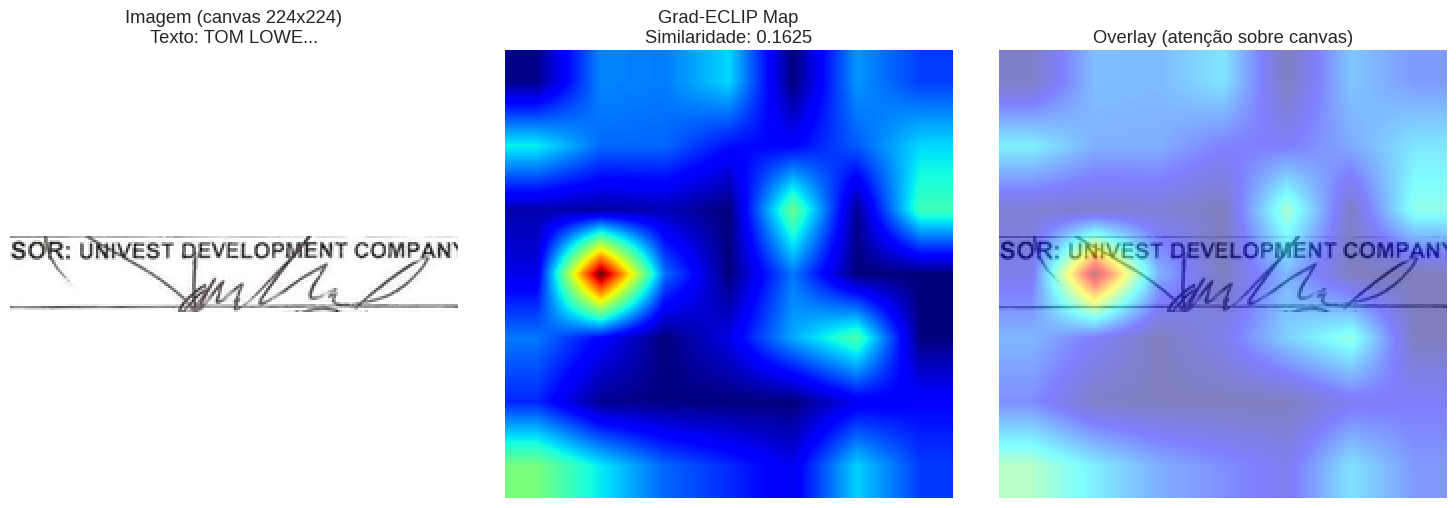


📊 Similaridade: 0.1625


In [17]:
# Testar Grad-ECLIP com uma amostra do dataset
if grad_eclip is not None and df_dataset is not None:
    sample = df_dataset.sample(1).iloc[0]
    
    images_base_path = project_root / "datasets" / "dataset-sign-align"
    image_path = str(images_base_path / sample['image_path'])
    text = sample['human_name']
    
    print(f"🔍 Teste Grad-ECLIP:")
    print(f"   Nome: {text}")
    print(f"   Imagem: {image_path}")
    
    result = grad_eclip.visualize(
        image_path=image_path,
        text=text,
        alpha=0.5
    )
    
    print(f"\n📊 Similaridade: {result['similarity']:.4f}")
else:
    print("⚠️ Grad-ECLIP ou dataset não disponível.")


In [21]:
import cv2, torch
import PIL.Image as Image
import torchvision.transforms as T

📊 Comparação Grad-ECLIP: Texto Correto vs Incorreto
   Imagem de: PHIL WURTH
   Texto correto: PHIL WURTH
   Texto incorreto: LISA ALEMAN


/tmp/ipykernel_27679/1320304224.py:67: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27679/1320304224.py:67: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27679/1320304224.py:68: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.savefig('article_outputs/img_grad/grad_eclip_comparison.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_27679/1320304224.py:68: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.savefig('article_outputs/img_grad/grad_eclip_comparison.png', dpi=150, bbox_inches='tight')
/home/lucas/Documentos/PósGaduação/UFPR/Mestrado/Projeto/Experimentos/SigAlignGit/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lucas/Document

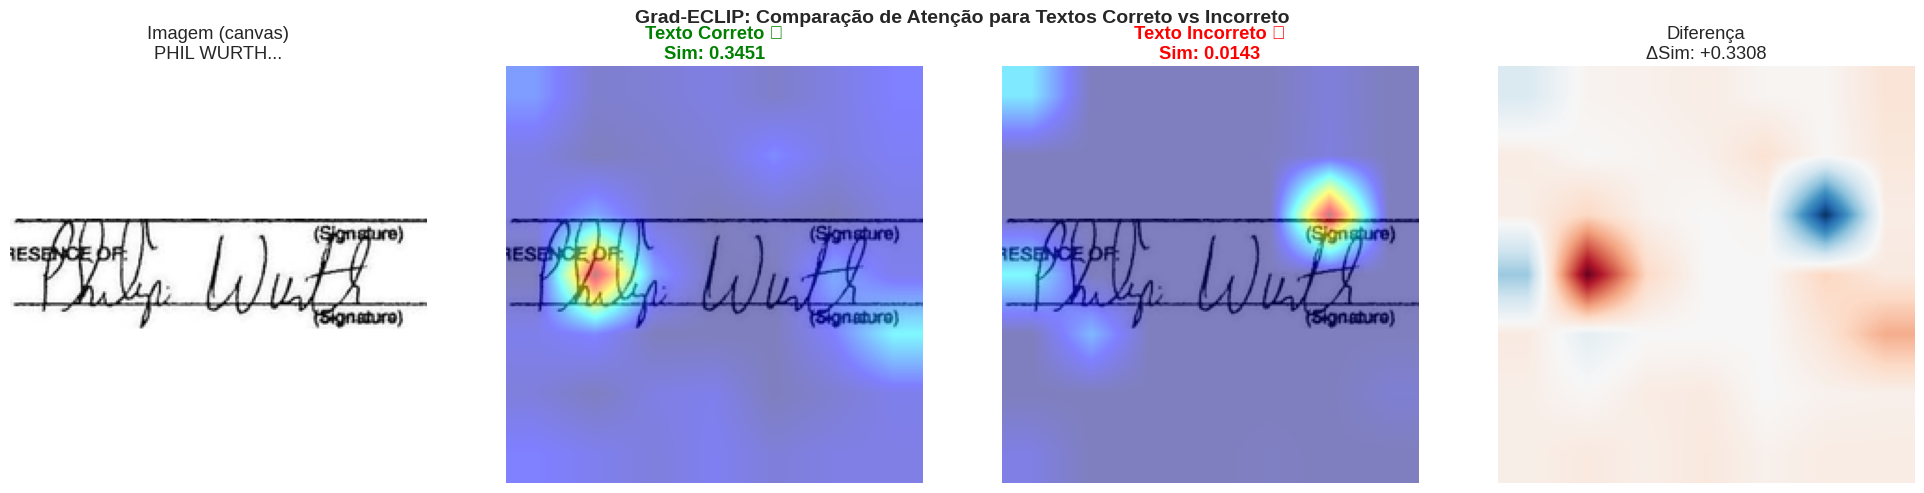


📈 Resultados:
   Similaridade (correto):  0.3451
   Similaridade (incorreto): 0.0143
   Diferença: +0.3308


In [32]:
# Comparação: Mesmo vs Diferente (demonstra poder discriminativo)
if grad_eclip is not None and df_dataset is not None:
    # Selecionar duas amostras com nomes diferentes
    unique_names = df_dataset['human_name'].unique()
    selected_names = np.random.choice(unique_names, 2, replace=False)
    
    sample1 = df_dataset[df_dataset['human_name'] == selected_names[0]].iloc[0]
    sample2 = df_dataset[df_dataset['human_name'] == selected_names[1]].iloc[0]
    
    images_base_path = project_root / "datasets" / "dataset-sign-align"
    image_path = str(images_base_path / sample1['image_path'])
    correct_text = sample1['human_name']
    wrong_text = sample2['human_name']
    
    print(f"📊 Comparação Grad-ECLIP: Texto Correto vs Incorreto")
    print(f"   Imagem de: {correct_text}")
    print(f"   Texto correto: {correct_text}")
    print(f"   Texto incorreto: {wrong_text}")
    
    # Carregar imagem processada (canvas 224x224 - igual ao treinamento)
    canvas_size = 224
    image_processed = grad_eclip._paste_center_on_canvas(Image.open(image_path))
    
    # Computar para ambos os textos (usar imagem processada)
    map_correct, sim_correct = grad_eclip.compute_grad_eclip(image_processed, correct_text)
    map_wrong, sim_wrong = grad_eclip.compute_grad_eclip(image_processed, wrong_text)
    
    # Resize para tamanho do canvas (224x224)
    resize = T.Resize((canvas_size, canvas_size), interpolation=T.InterpolationMode.BILINEAR)
    map_correct_resized = resize(torch.from_numpy(map_correct).unsqueeze(0))[0].numpy()
    map_wrong_resized = resize(torch.from_numpy(map_wrong).unsqueeze(0))[0].numpy()
    
    # Criar overlays (usar imagem processada para manter alinhamento espacial)
    image_np = np.array(image_processed)
    alpha = 0.5
    
    heatmap_correct = cv2.applyColorMap((map_correct_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_correct = cv2.cvtColor(heatmap_correct, cv2.COLOR_BGR2RGB)
    overlay_correct = np.clip(image_np * (1-alpha) + heatmap_correct * alpha, 0, 255).astype(np.uint8)
    
    heatmap_wrong = cv2.applyColorMap((map_wrong_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_wrong = cv2.cvtColor(heatmap_wrong, cv2.COLOR_BGR2RGB)
    overlay_wrong = np.clip(image_np * (1-alpha) + heatmap_wrong * alpha, 0, 255).astype(np.uint8)
    
    # Visualizar
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    axes[0].imshow(image_processed)
    axes[0].set_title(f"Imagem (canvas)\n{correct_text[:25]}...")
    axes[0].axis('off')
    
    axes[1].imshow(overlay_correct)
    axes[1].set_title(f"Texto Correto ✓\nSim: {sim_correct:.4f}", color='green', fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(overlay_wrong)
    axes[2].set_title(f"Texto Incorreto ✗\nSim: {sim_wrong:.4f}", color='red', fontweight='bold')
    axes[2].axis('off')
    
    # Diferença entre mapas
    diff_map = map_correct_resized - map_wrong_resized
    axes[3].imshow(diff_map, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[3].set_title(f"Diferença\nΔSim: {sim_correct - sim_wrong:+.4f}")
    axes[3].axis('off')
    
    plt.suptitle("Grad-ECLIP: Comparação de Atenção para Textos Correto vs Incorreto", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('article_outputs/img_grad/grad_eclip_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n📈 Resultados:")
    print(f"   Similaridade (correto):  {sim_correct:.4f}")
    print(f"   Similaridade (incorreto): {sim_wrong:.4f}")
    print(f"   Diferença: {sim_correct - sim_wrong:+.4f}")


## 6. 🎯 Aplicação Prática: Recuperação de Assinaturas em Documentos Multi-Assinatura

**Cenário Real**: Dado um documento com múltiplas assinaturas, o modelo consegue identificar corretamente qual assinatura pertence a qual nome?

**Protocolo de Avaliação**:
1. Selecionar documentos com 2+ assinaturas (excluindo UNKNOWN)
2. Para cada documento: dado um nome, verificar se o modelo retorna a assinatura correta como mais similar
3. Calcular Accuracy@1 (top-1), Accuracy@2 (nas 2 primeiras), etc.


In [33]:
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm
from PIL import Image

# Pré-processamento igual ao treinamento
def paste_center_on_canvas(img, canvas_size=224, background=(255, 255, 255)):
    """Centraliza imagem em canvas quadrado com background branco."""
    img = img.convert("RGBA")
    w, h = img.size
    scale = min(canvas_size / w, canvas_size / h)
    new_w, new_h = int(w * scale), int(h * scale)
    img_resized = img.resize((new_w, new_h), Image.LANCZOS)
    canvas = Image.new("RGBA", (canvas_size, canvas_size), color=background + (255,))
    offset = ((canvas_size - new_w) // 2, (canvas_size - new_h) // 2)
    canvas.paste(img_resized, offset, img_resized)
    return canvas.convert("RGB")

def prepare_multi_signature_documents(df, min_signatures=2):
    """Prepara documentos com múltiplas assinaturas para avaliação."""
    df_known = df[df['human_name'] != 'UNKNOWN'].copy()
    doc_groups = df_known.groupby('document')
    
    valid_docs = {}
    for doc_name, group in doc_groups:
        unique_signers = group['human_name'].nunique()
        if unique_signers >= min_signatures:
            signatures = []
            for name in group['human_name'].unique():
                sample = group[group['human_name'] == name].iloc[0]
                signatures.append({
                    'name': name,
                    'image_path': sample['image_path']
                })
            valid_docs[doc_name] = signatures
    
    return valid_docs

# Carregar dataset completo
dataset_path = project_root / "datasets" / "dataset-sign-align" / "dataset.csv"
df_full = pd.read_csv(dataset_path)

# Preparar documentos multi-assinatura
multi_sig_docs = prepare_multi_signature_documents(df_full, min_signatures=2)

print(f"📊 Estatísticas de Documentos Multi-Assinatura:")
print(f"   Total de documentos válidos: {len(multi_sig_docs)}")

sig_counts = [len(sigs) for sigs in multi_sig_docs.values()]
print(f"\n   Distribuição de assinaturas por documento:")
for n in sorted(set(sig_counts)):
    count = sig_counts.count(n)
    print(f"     {n} assinaturas: {count} documentos")

print(f"\n   Total de queries (nome→assinatura): {sum(sig_counts)}")


📊 Estatísticas de Documentos Multi-Assinatura:
   Total de documentos válidos: 1115

   Distribuição de assinaturas por documento:
     2 assinaturas: 693 documentos
     3 assinaturas: 412 documentos
     4 assinaturas: 5 documentos
     5 assinaturas: 1 documentos
     7 assinaturas: 2 documentos
     8 assinaturas: 2 documentos

   Total de queries (nome→assinatura): 2677


In [34]:
def evaluate_signature_retrieval(predictor, documents, images_base_path, show_progress=True, image_size=224):
    """Avalia o modelo na tarefa de recuperação de assinaturas."""
    model = predictor.model
    processor = predictor.processor
    device = predictor.device
    
    model.model.eval()
    
    results = []
    all_ranks = []
    correct_top1 = 0
    correct_top2 = 0
    total_queries = 0
    
    doc_iterator = tqdm(documents.items(), desc="Avaliando documentos") if show_progress else documents.items()
    
    with torch.no_grad():
        for doc_name, signatures in doc_iterator:
            n_sigs = len(signatures)
            
            images = []
            names = []
            
            for sig in signatures:
                img_path = images_base_path / sig['image_path']
                img = Image.open(img_path)
                img = paste_center_on_canvas(img, canvas_size=image_size)
                images.append(img)
                names.append(sig['name'])
            
            image_inputs = processor(images=images, return_tensors="pt", padding=True)
            image_inputs = {k: v.to(device) for k, v in image_inputs.items() if k == 'pixel_values'}
            
            image_embeds = model.get_image_features(**image_inputs)
            image_embeds = F.normalize(image_embeds, dim=-1)
            
            for query_idx, query_name in enumerate(names):
                text_inputs = processor(text=[query_name], return_tensors="pt", padding=True)
                text_inputs = {k: v.to(device) for k, v in text_inputs.items() if k in ['input_ids', 'attention_mask']}
                
                text_embed = model.get_text_features(**text_inputs)
                text_embed = F.normalize(text_embed, dim=-1)
                
                similarities = (text_embed @ image_embeds.T).squeeze(0).cpu().numpy()
                ranking = np.argsort(-similarities)
                correct_rank = np.where(ranking == query_idx)[0][0] + 1
                all_ranks.append(correct_rank)
                
                if correct_rank == 1:
                    correct_top1 += 1
                if correct_rank <= 2:
                    correct_top2 += 1
                
                total_queries += 1
                
                results.append({
                    'document': doc_name,
                    'query_name': query_name,
                    'n_candidates': n_sigs,
                    'correct_rank': correct_rank,
                    'is_top1': correct_rank == 1,
                    'similarities': similarities.tolist(),
                    'names': names
                })
    
    metrics = {
        'total_documents': len(documents),
        'total_queries': total_queries,
        'accuracy_top1': correct_top1 / total_queries,
        'accuracy_top2': correct_top2 / total_queries,
        'mean_rank': np.mean(all_ranks),
        'median_rank': np.median(all_ranks),
        'mrr': np.mean([1/r for r in all_ranks]),
    }
    
    return metrics, results, all_ranks

# Executar avaliação
if predictor is not None:
    print("🔍 Iniciando avaliação prática de recuperação de assinaturas...")
    print("=" * 70)

    images_base_path = project_root / "datasets" / "dataset-sign-align"

    metrics, practical_results, ranks = evaluate_signature_retrieval(
        predictor, 
        multi_sig_docs, 
        images_base_path,
        show_progress=True
    )

    print("\n" + "=" * 70)
    print("📊 RESULTADOS DA AVALIAÇÃO PRÁTICA")
    print("=" * 70)
    print(f"\n📁 Documentos avaliados: {metrics['total_documents']}")
    print(f"🔍 Total de queries (nome→assinatura): {metrics['total_queries']}")
    print(f"\n📈 Métricas de Recuperação:")
    print(f"   Accuracy@1 (Top-1):  {metrics['accuracy_top1']:.4f} ({metrics['accuracy_top1']*100:.2f}%)")
    print(f"   Accuracy@2 (Top-2):  {metrics['accuracy_top2']:.4f} ({metrics['accuracy_top2']*100:.2f}%)")
    print(f"   Mean Rank:           {metrics['mean_rank']:.2f}")
    print(f"   Median Rank:         {metrics['median_rank']:.1f}")
    print(f"   MRR:                 {metrics['mrr']:.4f}")
else:
    print("⚠️ Predictor não disponível para avaliação prática.")


🔍 Iniciando avaliação prática de recuperação de assinaturas...


Avaliando documentos:   0%|          | 0/1115 [00:00<?, ?it/s]


📊 RESULTADOS DA AVALIAÇÃO PRÁTICA

📁 Documentos avaliados: 1115
🔍 Total de queries (nome→assinatura): 2677

📈 Métricas de Recuperação:
   Accuracy@1 (Top-1):  0.9836 (98.36%)
   Accuracy@2 (Top-2):  0.9993 (99.93%)
   Mean Rank:           1.02
   Median Rank:         1.0
   MRR:                 0.9917


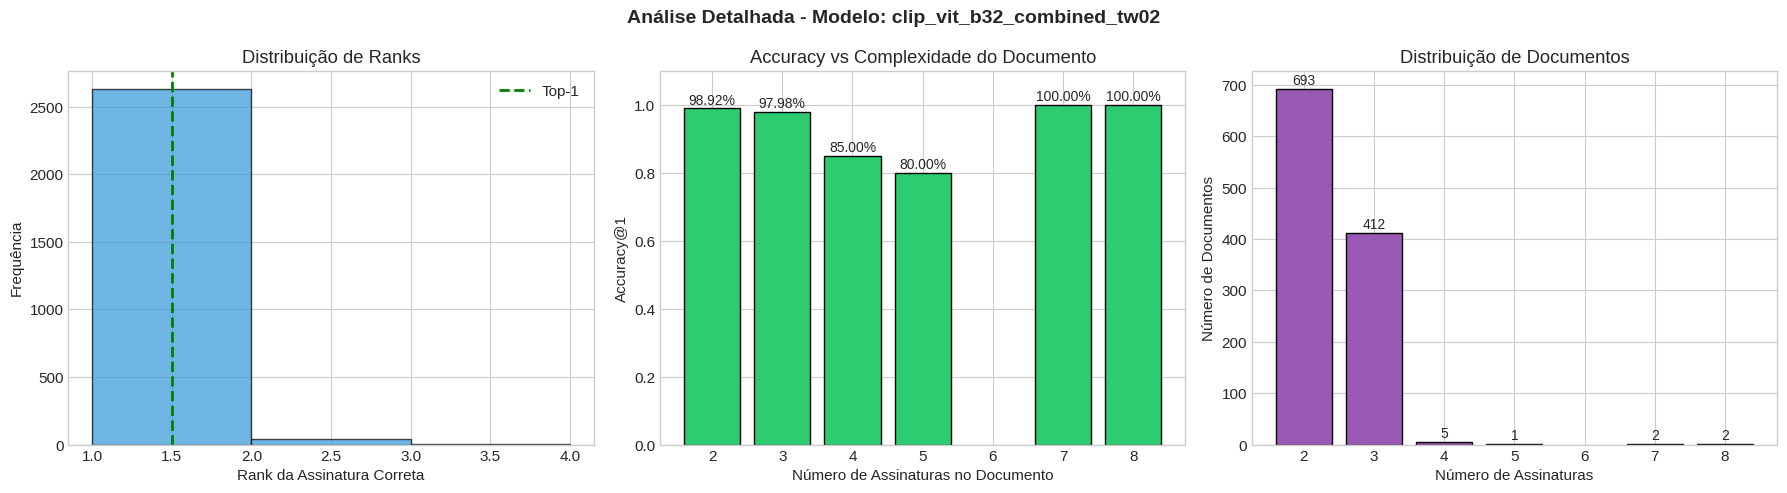


📊 Accuracy por Número de Candidatos:


,Documentos,Queries,Acc@1,Mean Rank,Median Rank
n_candidates,,,,,
2,693,1386,0.9892,1.0108,1.0
3,412,1236,0.9798,1.0218,1.0
4,5,20,0.8500,1.1500,1.0
5,1,5,0.8000,1.2000,1.0
7,2,14,1.0000,1.0000,1.0
8,2,16,1.0000,1.0000,1.0


In [36]:
# Análise detalhada dos resultados
df_results = pd.DataFrame(practical_results)

# Visualização 1: Distribuição dos ranks
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma dos ranks
ax1 = axes[0]
ax1.hist(ranks, bins=range(1, max(ranks)+2), edgecolor='black', alpha=0.7, color='#3498db')
ax1.axvline(x=1.5, color='green', linestyle='--', linewidth=2, label='Top-1')
ax1.set_xlabel('Rank da Assinatura Correta')
ax1.set_ylabel('Frequência')
ax1.set_title('Distribuição de Ranks')
ax1.legend()

# Accuracy por número de candidatos
ax2 = axes[1]
acc_by_candidates = df_results.groupby('n_candidates')['is_top1'].mean()
bars = ax2.bar(acc_by_candidates.index, acc_by_candidates.values, color='#2ecc71', edgecolor='black')
ax2.set_xlabel('Número de Assinaturas no Documento')
ax2.set_ylabel('Accuracy@1')
ax2.set_title('Accuracy vs Complexidade do Documento')
ax2.set_ylim(0, 1.1)
for bar, val in zip(bars, acc_by_candidates.values):
    ax2.annotate(f'{val:.2%}', xy=(bar.get_x() + bar.get_width()/2, val),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

# Distribuição de documentos por número de assinaturas
ax3 = axes[2]
doc_counts = df_results.groupby('n_candidates').apply(lambda x: x['document'].nunique())
ax3.bar(doc_counts.index, doc_counts.values, color='#9b59b6', edgecolor='black')
ax3.set_xlabel('Número de Assinaturas')
ax3.set_ylabel('Número de Documentos')
ax3.set_title('Distribuição de Documentos')
for i, v in enumerate(doc_counts.values):
    ax3.annotate(str(v), xy=(doc_counts.index[i], v), xytext=(0, 3), 
                 textcoords="offset points", ha='center', fontsize=10)

plt.suptitle(f'Análise Detalhada - Modelo: {SELECTED_EXPERIMENT}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('practical_evaluation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela resumo por complexidade
print("\n📊 Accuracy por Número de Candidatos:")
summary = df_results.groupby('n_candidates').agg({
    'document': 'nunique',
    'query_name': 'count',
    'is_top1': 'mean',
    'correct_rank': ['mean', 'median']
}).round(4)
summary.columns = ['Documentos', 'Queries', 'Acc@1', 'Mean Rank', 'Median Rank']
display(summary)


In [38]:
df_results

,document,query_name,n_candidates,correct_rank,is_top1,similarities,names
0,agw39d00,CECIL R HATTON,8,1,True,"[0.5009329915046692, -0.042521584779024124, 0....","[CECIL R HATTON, COLIN STOKES, G D SMITH, J H ..."
1,agw39d00,COLIN STOKES,8,1,True,"[0.037963543087244034, 0.6041198372840881, -0....","[CECIL R HATTON, COLIN STOKES, G D SMITH, J H ..."
2,agw39d00,G D SMITH,8,1,True,"[-0.05765922740101814, -0.14776964485645294, 0...","[CECIL R HATTON, COLIN STOKES, G D SMITH, J H ..."
3,agw39d00,J H SHERRILL,8,1,True,"[-0.08766908198595047, -0.0973200649023056, 0....","[CECIL R HATTON, COLIN STOKES, G D SMITH, J H ..."
4,agw39d00,J H WINDER,8,1,True,"[-0.06504850834608078, -0.2024974226951599, 0....","[CECIL R HATTON, COLIN STOKES, G D SMITH, J H ..."
...,...,...,...,...,...,...,...
2672,zkd43f00_2,RUFUS H HONEYCUTT,3,1,True,"[0.0534965954720974, 0.4708369970321655, 0.132...","[ELMER O HTZENGER JR, RUFUS H HONEYCUTT, THOMA..."
2673,zkd43f00_2,THOMAS C HEWITT,3,1,True,"[0.011481903493404388, 0.14126768708229065, 0....","[ELMER O HTZENGER JR, RUFUS H HONEYCUTT, THOMA..."
2674,zkd43f00_3,ELMER O HTZENGER JR,3,1,True,"[0.45278459787368774, 0.20813106000423431, 0.0...","[ELMER O HTZENGER JR, RUFUS H HONEYCUTT, THOMA..."
2675,zkd43f00_3,RUFUS H HONEYCUTT,3,1,True,"[0.1586894989013672, 0.5659101009368896, 0.020...","[ELMER O HTZENGER JR, RUFUS H HONEYCUTT, THOMA..."


In [39]:
# Visualização de exemplos: Sucesso e Falha
def visualize_retrieval_examples(df_results, images_base_path, n_success=3, n_failure=3):
    """
    Mostra exemplos visuais de recuperação de assinaturas.
    """
    # Selecionar exemplos de sucesso (rank=1) e falha (rank>1)
    successes = df_results[df_results['is_top1']].sample(min(n_success, len(df_results[df_results['is_top1']])))
    failures = df_results[~df_results['is_top1']]
    if len(failures) > 0:
        failures = failures.sample(min(n_failure, len(failures)))
    
    # Visualizar
    n_examples = len(successes) + len(failures)
    if n_examples == 0:
        print("Nenhum exemplo para visualizar")
        return
    
    fig, axes = plt.subplots(n_examples, 1, figsize=(16, 4*n_examples))
    if n_examples == 1:
        axes = [axes]
    
    plot_idx = 0
    
    # Plotar sucessos
    for _, row in successes.iterrows():
        ax = axes[plot_idx]
        names = row['names']
        sims = row['similarities']
        query = row['query_name']
        n_sigs = row['n_candidates']
        
        # Carregar e mostrar assinaturas
        images = []
        for i, name in enumerate(names):
            # Encontrar imagem correspondente
            sig = next(s for s in multi_sig_docs[row['document']] if s['name'] == name)
            img = Image.open(images_base_path / sig['image_path']).convert("RGB")
            images.append(img)
        
        # Criar subplot com imagens lado a lado
        for i, (img, name, sim) in enumerate(zip(images, names, sims)):
            # Criar subaxes
            sub_ax = fig.add_axes([0.05 + i*0.9/n_sigs, 0.95 - (plot_idx+1)*0.95/n_examples + 0.02, 
                                   0.85/n_sigs, 0.9/n_examples - 0.04])
            sub_ax.imshow(img)
            color = 'green' if name == query else 'gray'
            border_width = 3 if name == query else 1
            for spine in sub_ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(border_width)
            sub_ax.set_title(f"{name[:15]}...\nSim: {sim:.3f}", fontsize=9, 
                            color='green' if name == query else 'black',
                            fontweight='bold' if name == query else 'normal')
            sub_ax.axis('off')
        
        ax.axis('off')
        ax.set_title(f"✓ SUCESSO - Query: '{query}' | Documento: {row['document'][:30]}...", 
                    fontsize=12, fontweight='bold', color='green', loc='left')
        plot_idx += 1
    
    # Plotar falhas
    for _, row in failures.iterrows():
        ax = axes[plot_idx]
        names = row['names']
        sims = row['similarities']
        query = row['query_name']
        n_sigs = row['n_candidates']
        ranking = row['ranking']
        
        ax.axis('off')
        ax.set_title(f"✗ FALHA - Query: '{query}' | Rank: {row['correct_rank']} | Doc: {row['document'][:30]}...", 
                    fontsize=12, fontweight='bold', color='red', loc='left')
        plot_idx += 1
    
    plt.tight_layout()
    plt.savefig('retrieval_examples.png', dpi=150, bbox_inches='tight')
    plt.show()

# Mostrar exemplos simples (texto)
print("\n" + "=" * 70)
print("📌 EXEMPLOS DE RECUPERAÇÃO")
print("=" * 70)

# Exemplos de SUCESSO
print("\n✅ EXEMPLOS DE SUCESSO (Top-1 correto):")
successes = df_results[df_results['is_top1']].head(5)
for _, row in successes.iterrows():
    print(f"\n   Documento: {row['document'][:40]}...")
    print(f"   Query: '{row['query_name']}'")
    print(f"   Candidatos: {row['n_candidates']} assinaturas")
    print(f"   Similaridades: {[f'{s:.3f}' for s in row['similarities']]}")
    print(f"   Nomes: {row['names']}")

# Exemplos de FALHA
print("\n\n❌ EXEMPLOS DE FALHA (Top-1 incorreto):")
failures = df_results[~df_results['is_top1']]
if len(failures) > 0:
    for _, row in failures.head(5).iterrows():
        print(f"\n   Documento: {row['document'][:40]}...")
        print(f"   Query: '{row['query_name']}'")
        print(f"   Rank correto: {row['correct_rank']} de {row['n_candidates']}")
        print(f"   Similaridades: {[f'{s:.3f}' for s in row['similarities']]}")
        print(f"   Nomes: {row['names']}")
        #predicted_idx = row['ranking'][0]
        #print(f"   Predição Top-1: '{row['names'][predicted_idx]}' (sim={row['similarities'][predicted_idx]:.3f})")
else:
    print("   🎉 Nenhuma falha! O modelo acertou 100%!")



📌 EXEMPLOS DE RECUPERAÇÃO

✅ EXEMPLOS DE SUCESSO (Top-1 correto):

   Documento: agw39d00...
   Query: 'CECIL R HATTON'
   Candidatos: 8 assinaturas
   Similaridades: ['0.501', '-0.043', '0.071', '-0.024', '-0.096', '-0.218', '-0.059', '-0.034']
   Nomes: ['CECIL R HATTON', 'COLIN STOKES', 'G D SMITH', 'J H SHERRILL', 'J H WINDER', 'S O JONES', 'W STUART LEAKE', 'WM D HOBBS']

   Documento: agw39d00...
   Query: 'COLIN STOKES'
   Candidatos: 8 assinaturas
   Similaridades: ['0.038', '0.604', '-0.045', '-0.081', '-0.179', '0.075', '0.093', '0.058']
   Nomes: ['CECIL R HATTON', 'COLIN STOKES', 'G D SMITH', 'J H SHERRILL', 'J H WINDER', 'S O JONES', 'W STUART LEAKE', 'WM D HOBBS']

   Documento: agw39d00...
   Query: 'G D SMITH'
   Candidatos: 8 assinaturas
   Similaridades: ['-0.058', '-0.148', '0.614', '0.090', '-0.014', '0.013', '-0.041', '-0.011']
   Nomes: ['CECIL R HATTON', 'COLIN STOKES', 'G D SMITH', 'J H SHERRILL', 'J H WINDER', 'S O JONES', 'W STUART LEAKE', 'WM D HOBBS']

   D


📄 Visualizando documento: agw39d00


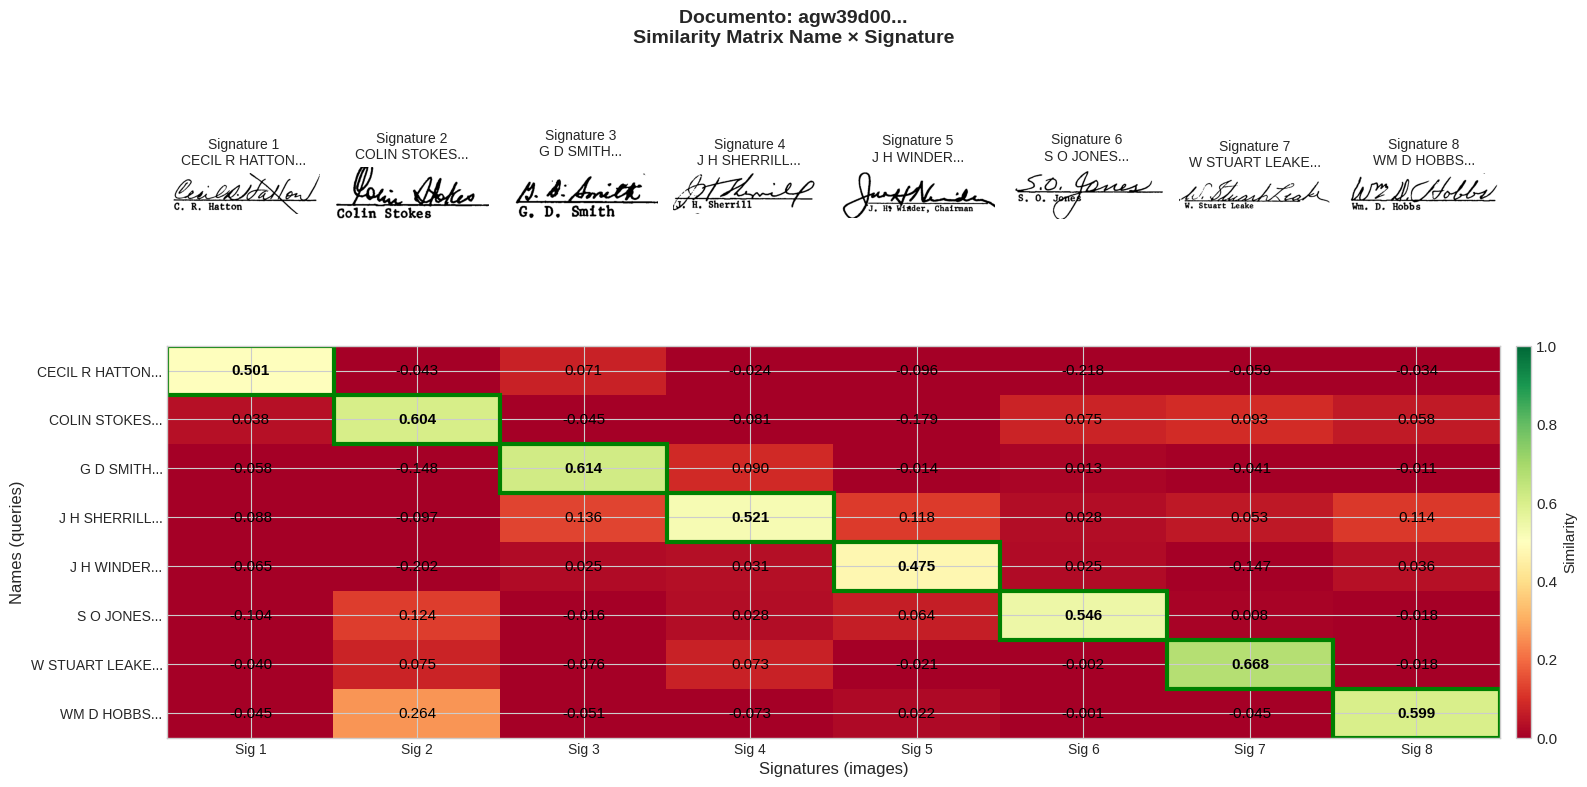


📊 Métricas do Documento:
   Número de assinaturas: 8
   Accuracy: 100.00%
   Predições: [0, 1, 2, 3, 4, 5, 6, 7]
   Correto:   [0, 1, 2, 3, 4, 5, 6, 7]


In [42]:
# Visualização de um documento específico com múltiplas assinaturas
def visualize_document_retrieval(doc_name, documents, predictor, images_base_path):
    """
    Visualiza o processo de retrieval para um documento específico.
    Mostra todas as assinaturas e a matriz de similaridade nome×assinatura.
    """
    if doc_name not in documents:
        print(f"Documento {doc_name} não encontrado!")
        return
    
    signatures = documents[doc_name]
    n_sigs = len(signatures)
    
    model = predictor.model
    processor = predictor.processor
    device = predictor.device
    
    # Carregar imagens e nomes COM O MESMO PRÉ-PROCESSAMENTO DO TREINAMENTO
    images = []
    images_processed = []  # Para o modelo
    names = []
    for sig in signatures:
        img_path = images_base_path / sig['image_path']
        img_raw = Image.open(img_path).convert("RGB")  # Para visualização
        img_processed = paste_center_on_canvas(Image.open(img_path), canvas_size=224)  # Para o modelo
        images.append(img_raw)
        images_processed.append(img_processed)
        names.append(sig['name'])
    
    # Obter embeddings
    model.model.eval()
    with torch.no_grad():
        # Imagens (usar as processadas com canvas!)
        image_inputs = processor(images=images_processed, return_tensors="pt", padding=True)
        image_inputs = {k: v.to(device) for k, v in image_inputs.items() if k == 'pixel_values'}
        image_embeds = model.get_image_features(**image_inputs)
        image_embeds = F.normalize(image_embeds, dim=-1)
        
        # Textos
        text_inputs = processor(text=names, return_tensors="pt", padding=True)
        text_inputs = {k: v.to(device) for k, v in text_inputs.items() if k in ['input_ids', 'attention_mask']}
        text_embeds = model.get_text_features(**text_inputs)
        text_embeds = F.normalize(text_embeds, dim=-1)
        
        # Matriz de similaridade
        sim_matrix = (text_embeds @ image_embeds.T).cpu().numpy()
    
    # Visualização
    fig = plt.figure(figsize=(16, 8))
    
    # Grid: assinaturas no topo, matriz embaixo
    gs = fig.add_gridspec(2, n_sigs + 1, height_ratios=[1, 1.5], width_ratios=[1]*n_sigs + [0.1])
    
    # Mostrar assinaturas
    for i, (img, name) in enumerate(zip(images, names)):
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(img)
        ax.set_title(f"Signature {i+1}\n{name[:20]}...", fontsize=10)
        ax.axis('off')
    
    # Matriz de similaridade
    ax_matrix = fig.add_subplot(gs[1, :-1])
    im = ax_matrix.imshow(sim_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    # Labels
    ax_matrix.set_xticks(range(n_sigs))
    ax_matrix.set_xticklabels([f"Sig {i+1}" for i in range(n_sigs)], fontsize=10)
    ax_matrix.set_yticks(range(n_sigs))
    ax_matrix.set_yticklabels([f"{n[:15]}..." for n in names], fontsize=10)
    ax_matrix.set_xlabel("Signatures (images)", fontsize=12)
    ax_matrix.set_ylabel("Names (queries)", fontsize=12)
    
    # Valores na matriz
    for i in range(n_sigs):
        for j in range(n_sigs):
            color = 'white' if sim_matrix[i, j] > 0.7 else 'black'
            weight = 'bold' if i == j else 'normal'
            ax_matrix.text(j, i, f'{sim_matrix[i, j]:.3f}', ha='center', va='center', 
                          color=color, fontweight=weight, fontsize=11)
    
    # Destacar diagonal (matches corretos)
    for i in range(n_sigs):
        rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor='green', linewidth=3)
        ax_matrix.add_patch(rect)
    
    # Colorbar
    ax_cb = fig.add_subplot(gs[1, -1])
    plt.colorbar(im, cax=ax_cb, label='Similarity')
    
    plt.suptitle(f"Documento: {doc_name[:50]}...\nSimilarity Matrix Name × Signature", 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('document_retrieval_example.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Calcular accuracy para este documento
    predictions = np.argmax(sim_matrix, axis=1)
    correct = np.arange(n_sigs)
    accuracy = (predictions == correct).mean()
    
    print(f"\n📊 Métricas do Documento:")
    print(f"   Número de assinaturas: {n_sigs}")
    print(f"   Accuracy: {accuracy:.2%}")
    print(f"   Predições: {predictions.tolist()}")
    print(f"   Correto:   {correct.tolist()}")

# Selecionar um documento com pelo menos 3 assinaturas para visualização interessante
docs_with_3plus = {k: v for k, v in multi_sig_docs.items() if len(v) >= 3}
if docs_with_3plus:
    sample_doc = list(docs_with_3plus.keys())[0]
    print(f"\n📄 Visualizando documento: {sample_doc}")
    visualize_document_retrieval(sample_doc, multi_sig_docs, predictor, images_base_path)
else:
    print("Nenhum documento com 3+ assinaturas encontrado")


## 7. 🏢 Análise do Dataset Interno (MÉTRICAS DE TESTE)

Esta seção analisa os resultados dos experimentos no dataset interno usando **métricas de TESTE**:

1. **Modelo Pré-treinado**: Avalia o modelo treinado no dataset original no dataset interno
2. **Fine-tuning**: Treina no dataset interno com a mesma configuração
3. **CLIP Frozen**: Baseline - CLIP original sem fine-tuning

**Nota**: São priorizadas métricas do conjunto de teste quando disponíveis.


In [43]:
# Carregar resultados dos experimentos internos
def load_internal_experiments(experiments_path):
    """Carrega resultados dos experimentos no dataset interno usando métricas de TESTE."""
    internal_path = experiments_path / "internal"
    
    experiments = {
        "pretrained": "internal_eval_pretrained",
        "finetuned": "internal_finetune_combined", 
        "frozen": "internal_clip_frozen"
    }
    
    results = {}
    
    for key, exp_name in experiments.items():
        exp_dir = internal_path / exp_name
        
        if not exp_dir.exists():
            print(f"⚠️ Experimento não encontrado: {exp_name}")
            continue
            
        # Carregar métricas de TESTE (prioridade) ou val_history como fallback
        test_metrics_file = exp_dir / "metrics" / "test_metrics.json"
        val_history_file = exp_dir / "metrics" / "val_history.json"
        
        if test_metrics_file.exists():
            with open(test_metrics_file) as f:
                metrics = json.load(f)
            metrics_source = "test"
        elif val_history_file.exists():
            with open(val_history_file) as f:
                val_history = json.load(f)
            # Extrair última época (usar métricas val como fallback)
            metrics = val_history[-1] if isinstance(val_history, list) and len(val_history) > 0 else {}
            metrics_source = "val_history"
        else:
            metrics = {}
            metrics_source = "none"
        
        # Carregar config
        config_file = exp_dir / "config.json"
        if config_file.exists():
            with open(config_file) as f:
                config = json.load(f)
        else:
            config = {}
        
        results[key] = {
            "name": exp_name,
            "metrics": metrics,
            "metrics_source": metrics_source,
            "config": config,
            "path": str(exp_dir)
        }
        
        print(f"✅ Carregado: {exp_name} (fonte: {metrics_source})")
    
    return results

# Carregar experimentos internos
internal_experiments_path = project_root / "experiments"
internal_results = load_internal_experiments(internal_experiments_path)

print(f"\n📊 Total de experimentos internos carregados: {len(internal_results)}")


⚠️ Experimento não encontrado: internal_eval_pretrained
⚠️ Experimento não encontrado: internal_finetune_combined
⚠️ Experimento não encontrado: internal_clip_frozen

📊 Total de experimentos internos carregados: 0


In [ ]:
# Comparação de métricas do dataset interno (MÉTRICAS DE TESTE)
def compare_internal_metrics(results):
    """Compara métricas de TESTE entre os experimentos do dataset interno."""
    
    if not results:
        print("❌ Nenhum resultado para comparar")
        return None
    
    # Métricas de TESTE (com fallback para val_ caso test_ não exista)
    metric_keys = [
        ("accuracy_1_neg", "Accuracy (1 neg)"),
        ("accuracy_2_neg", "Accuracy (2 neg)"),
        ("accuracy_3_neg", "Accuracy (3 neg)"),
        ("mean_pos_similarity", "Sim+ (média)"),
        ("mean_neg_similarity", "Sim- (média)"),
        ("similarity_gap_3_neg", "Gap"),
    ]
    
    data = []
    for key, result in results.items():
        metrics = result["metrics"]
        metrics_source = result.get("metrics_source", "unknown")
        
        row = {
            "Experimento": key.replace("_", " ").title(),
            "Nome": result["name"],
            "Fonte": metrics_source
        }
        
        for metric_key, metric_name in metric_keys:
            # Tentar test_ primeiro, depois val_, depois sem prefixo
            value = metrics.get(f"test_{metric_key}") or metrics.get(f"val_{metric_key}") or metrics.get(metric_key)
            row[metric_name] = value
        data.append(row)
    
    return pd.DataFrame(data)

# Comparar métricas
if internal_results:
    df_internal_compare = compare_internal_metrics(internal_results)

    if df_internal_compare is not None and len(df_internal_compare) > 0:
        print("=" * 80)
        print("📊 COMPARAÇÃO: Dataset Interno (MÉTRICAS DE TESTE)")
        print("=" * 80)
        
        for _, row in df_internal_compare.iterrows():
            print(f"\n🔹 {row['Experimento']} ({row['Nome']}) - Fonte: {row['Fonte']}")
            for col in df_internal_compare.columns:
                if col not in ["Experimento", "Nome", "Fonte"] and row[col] is not None:
                    print(f"   {col}: {row[col]:.4f}")
else:
    print("⚠️ Nenhum experimento interno encontrado. Execute os experimentos primeiro.")
